# MVP Recipe Subset Curation

This notebook creates a non-destructive derived dataset for MVP recipe indexing.

It reads from the existing v4 portion feasibility artifacts and creates a separate curated recipe subset with:

- Fully gram-resolved recipes
- LLM-assisted cuisine tags
- Cuisine confidence and review flags
- Underrepresented-cuisine indicators
- Nutrient-profile tags once macro totals are available
- A final MVP recipe subset for indexing

This notebook does **not** modify source datasets, Supabase tables, RecipeNLG, USDA data, or existing feasibility outputs. All new outputs are written to a separate derived curation folder.

In [78]:
from pathlib import Path
import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 250)
pd.set_option("display.max_columns", 100)

# Make relative paths work regardless of where Jupyter starts.
ROOT = Path(r"C:\Users\winni\Documents\GitHub\Capstone\Capstone")
os.chdir(ROOT)

print("Current working directory:")
print(Path.cwd())

# Existing artifacts: read-only inputs
BASELINE_DIR = ROOT / "scratch" / "EDA" / "portion_feasibility_1000"
V4_DIR = ROOT / "scratch" / "EDA" / "portion_feasibility_1000_v4_no_portion"

# Prefer v4 if it exists and has final outputs; otherwise use baseline
if (V4_DIR / "pipeline_matches.parquet").exists():
    INPUT_DIR = V4_DIR
else:
    INPUT_DIR = BASELINE_DIR

MATCHES_PATH = INPUT_DIR / "pipeline_matches.parquet"
REPORT_PATH = INPUT_DIR / "feasibility_report.json"

# New derived outputs
OUT_DIR = ROOT / "scratch" / "EDA" / "mvp_recipe_curation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Candidate input directory:", INPUT_DIR)
print("Pipeline matches path:", MATCHES_PATH)
print("Report path:", REPORT_PATH)
print("Derived output directory:", OUT_DIR)

Current working directory:
C:\Users\winni\Documents\GitHub\Capstone\Capstone
Candidate input directory: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\portion_feasibility_1000
Pipeline matches path: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\portion_feasibility_1000\pipeline_matches.parquet
Report path: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\portion_feasibility_1000\feasibility_report.json
Derived output directory: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\mvp_recipe_curation


In [79]:
if "lines" in globals() and lines is not None:
    print(lines.columns.tolist())
else:
    print("lines has not been loaded yet. Run the loading cell first.")

['run_id', 'run_name', 'model', 'recipe_id', 'ingredient_idx', 'ingredient', 'name', 'preparation', 'dequantified', 'unit', 'quantity', 'amount_kind', 'retrieval_tier', 'portion_filter_kind', 'n_tier1_union', 'tier1_max_score', 'system_prompt', 'prompt', 'response', 'llm_fdc_id', 'llm_description', 'llm_certainty', 'llm_rationale', 'matched_portion_id', 'llm_negligible_calories', 'llm_pick_has_volume_portion', 'llm_pick_has_count_portion', 'grams', 'grams_status', 'grams_method', 'pipeline_path', 'llm_agrees_with_staged', 'llm_abstained', 'llm_error', 'staged_fdc_id', 'staged_description', 'staged_match_score', 'staged_match_quality', 'staged_base_score', 'staged_prep_score', 'n_candidates_llm', 'n_lexical_pool', 'n_semantic_pool', 'staged_top1_in_llm_candidates', 'staged_top1_in_top10', 'n_relevant_steps', 'relevant_steps', 'prompt_tokens', 'completion_tokens', 'total_tokens', 'price_estimate_usd', 'prompt_version', 'ts', 'ts_year', 'ts_month', 'ts_date', 'ts_time', 'amount_kind_final

## Data safety note

This notebook only reads from generated feasibility artifacts, such as:

- `scratch/EDA/portion_feasibility_1000/pipeline_matches.parquet`
- `scratch/EDA/portion_feasibility_1000/feasibility_report.json`
- or the v4 no-portion retry equivalents if available

It writes new derived curation outputs under:

- `scratch/EDA/mvp_recipe_curation/`

It does not overwrite RecipeNLG, USDA data, Supabase tables, or existing feasibility outputs.

In [80]:
required_paths = {
    "pipeline_matches": MATCHES_PATH,
    "feasibility_report": REPORT_PATH,
}

for name, path in required_paths.items():
    print(f"{name}: {path} | exists={path.exists()}")

if not MATCHES_PATH.exists():
    print("\nPipeline output is not ready yet.")
    print("You can continue defining helper functions, but recipe curation will run after pipeline_matches.parquet exists.")
else:
    print("\nReady to load pipeline outputs.")

pipeline_matches: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\portion_feasibility_1000\pipeline_matches.parquet | exists=True
feasibility_report: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\portion_feasibility_1000\feasibility_report.json | exists=True

Ready to load pipeline outputs.


loading 

In [81]:
if MATCHES_PATH.exists():
    lines = pd.read_parquet(MATCHES_PATH)

    if REPORT_PATH.exists():
        with open(REPORT_PATH, "r") as f:
            report = json.load(f)
    else:
        report = {}

    print(f"Loaded line-level rows: {len(lines):,}")
    print(f"Loaded columns: {len(lines.columns):,}")
    display(lines.head())
else:
    lines = None
    report = {}

Loaded line-level rows: 8,754
Loaded columns: 68


,run_id,run_name,model,recipe_id,ingredient_idx,ingredient,name,preparation,dequantified,unit,quantity,amount_kind,retrieval_tier,portion_filter_kind,n_tier1_union,tier1_max_score,system_prompt,prompt,response,llm_fdc_id,llm_description,llm_certainty,llm_rationale,matched_portion_id,llm_negligible_calories,llm_pick_has_volume_portion,llm_pick_has_count_portion,grams,grams_status,grams_method,pipeline_path,llm_agrees_with_staged,llm_abstained,llm_error,staged_fdc_id,staged_description,staged_match_score,staged_match_quality,staged_base_score,staged_prep_score,n_candidates_llm,n_lexical_pool,n_semantic_pool,staged_top1_in_llm_candidates,staged_top1_in_top10,n_relevant_steps,relevant_steps,prompt_tokens,completion_tokens,total_tokens,price_estimate_usd,prompt_version,ts,ts_year,ts_month,ts_date,ts_time,amount_kind_final,amount_kind_rules,amount_kind_source,needs_portion,rules_grams,rules_grams_status,rules_grams_method,usda_portion_available,portion_llm_certainty,portion_llm_rationale,portion_resolved_by_llm
0,eaead5959af04e1a9abe28496d205137,feasibility_1000_seed42,gpt-4o-mini,1702,0,"1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes",ready-to-cook red potatoes,refrigerated,"bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes",bag,1.00,mass,mass_in_text,None,34,0.5700,"You match one recipe ingredient to the best USDA FoodData Central entry (fdc_id) for nutrition lookup.\nEach candidate line is formatted `fdc_id | description | L | S | P | portions | fit`:\n L = lexical score; S = semantic score (0-1, higher = ...","INGREDIENT: 1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes\nPARSED: name=ready-to-cook red potatoes; prep=refrigerated; unit=bag; amount_kind=mass\nNOTE: Recipe line includes explicit mass; grams will convert from mass directly.\n\nCA...",None,None,None,None,None,None,False,False,False,None,missing_fdc,no fdc_id,mass→mass_in_text→llm→abstain→missing_fdc,False,False,RuntimeError: No OpenAI API key configured. Set OPENAI_API_KEY (and optionally OPENAI_API_KEY_2) in .env,1115891.0,RED POTATOES,0.5059,low,0.5376,0.2660,10,12,30,True,True,1,"Cook potatoes according to package directions. Drain in colander under cool running water, 30 seconds.",0,0,0,0.0,v4_portion_good_enough,2026-06-14 23:51:04.487040+00:00,2026,6,14,23:51:04,mass,count,rules,True,None,missing_fdc,no fdc_id,False,None,None,False
1,eaead5959af04e1a9abe28496d205137,feasibility_1000_seed42,gpt-4o-mini,1702,1,1/4 c. mayonnaise,mayonnaise,,c. mayonnaise,c,0.25,volume,portion_ranked,volume,53,0.8003,"You match one recipe ingredient to the best USDA FoodData Central entry (fdc_id) for nutrition lookup.\nEach candidate line is formatted `fdc_id | description | L | S | P | portions | fit`:\n L = lexical score; S = semantic score (0-1, higher = ...","INGREDIENT: 1/4 c. mayonnaise\nPARSED: name=mayonnaise; prep=-; unit=c; amount_kind=volume\nPORTION_QUERY_TOKENS: c\n\nCANDIDATES (fdc_id | description | L | S | P | portions | fit):\n P = V volume, C count, Cm container-mass (e.g. can), VC both...",None,None,None,None,None,None,False,False,False,None,missing_fdc,no fdc_id,volume→portion_ranked→llm→abstain→missing_fdc,False,False,RuntimeError: No OpenAI API key configured. Set OPENAI_API_KEY (and optionally OPENAI_API_KEY_2) in .env,1129359.0,MAYONNAISE,0.6823,medium,0.7435,0.4362,4,12,50,False,False,0,,0,0,0,0.0,v4_portion_good_enough,2026-06-14 23:51:04.487040+00:00,2026,6,14,23:51:04,volume,volume,rules,True,None,missing_fdc,no fdc_id,False,None,None,False
2,eaead5959af04e1a9abe28496d205137,feasibility_1000_seed42,gpt-4o-mini,1702,2,1/4 c. chopped kosher dill pickles,kosher dill pickles,chopped,c. chopped kosher dill pickles,c,0.25,volume,portion_ranked,volume,99,0.7954,"You match one recipe ingredient to the best USDA FoodData Central entry (fdc_id) for nutrition lookup.\nEach candidate line is formatted `fdc_id | description | L | S | P | portions | fit`:\n L = lexical score; S = semantic score (0-1, higher = ...","INGREDIENT: 1/4 c. chop

column helpers

In [82]:
def first_existing_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def detect_columns(lines):
    return {
        "recipe_id_col": first_existing_col(lines, ["recipe_id", "nlg_id", "id"]),
        "title_col": first_existing_col(lines, ["title", "recipe_title"]),

        # Original ingredient line, best for LLM context.
        "ingredient_col": first_existing_col(lines, ["ingredient_line", "ingredient", "ingredients"]),

        # Parsed ingredient name, useful for keyword-based cuisine tagging.
        "ingredient_name_col": first_existing_col(lines, ["name", "ingredient_name", "parsed_name"]),

        "source_col": first_existing_col(lines, ["source"]),
        "link_col": first_existing_col(lines, ["link", "url"]),
    }


if lines is not None:
    colmap = detect_columns(lines)
    print(colmap)

{'recipe_id_col': 'recipe_id', 'title_col': None, 'ingredient_col': 'ingredient', 'ingredient_name_col': 'name', 'source_col': None, 'link_col': None}


In [83]:
# Ingredient-focused diagnostic.
# For this notebook, we care about recipe IDs and ingredient text, not gram resolution.

if lines is not None:
    display(
        lines[
            [c for c in [
                "recipe_id",
                "ingredient_idx",
                "ingredient",
                "name",
                "preparation",
                "dequantified",
                "amount_kind",
            ] if c in lines.columns]
        ].head(25)
    )

    print(f"Line-level ingredient rows: {len(lines):,}")
    print(f"Unique recipes: {lines['recipe_id'].nunique():,}")

,recipe_id,ingredient_idx,ingredient,name,preparation,dequantified,amount_kind
0,1702,0,"1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes",ready-to-cook red potatoes,refrigerated,"bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes",mass
1,1702,1,1/4 c. mayonnaise,mayonnaise,,c. mayonnaise,volume
2,1702,2,1/4 c. chopped kosher dill pickles,kosher dill pickles,chopped,c. chopped kosher dill pickles,volume
3,1702,3,2 Tbsp. finely chopped shallot,shallot,finely chopped,Tbsp. finely chopped shallot,volume
4,1702,4,1 Tbsp white wine vinegar,white wine vinegar,,Tbsp white wine vinegar,volume
5,1702,5,1/2 Tsp sugar,sugar,,Tsp sugar,volume
6,1702,6,1/2 Tsp salt,salt,,Tsp salt,volume
7,1702,7,1 Tsp olive oil,olive oil,,Tsp olive oil,volume
8,1702,8,"1 cup frozen whole-kernel corn, partially thawed",frozen whole-kernel corn,partially thawed,"cup frozen whole-kernel corn, partially thawed",volume
9,2398,0,1 stick margarine,margarine,,stick margarine,count


Line-level ingredient rows: 8,754
Unique recipes: 1,000


## Build recipe-level candidate pool

The feasibility pipeline output is line-level, with one row per ingredient. For MVP recipe selection, we need a recipe-level table that summarizes resolution status, ingredient text, source, and link.

In [84]:
def join_unique_text(values, sep=" | "):
    cleaned = (
        pd.Series(values)
        .dropna()
        .astype(str)
        .str.strip()
    )
    cleaned = cleaned[cleaned != ""]

    # Preserve original order while removing duplicates.
    seen = set()
    unique_values = []
    for value in cleaned:
        key = value.lower()
        if key not in seen:
            seen.add(key)
            unique_values.append(value)

    return sep.join(unique_values)


def build_recipe_ingredient_pool(lines):
    colmap = detect_columns(lines)

    recipe_id_col = colmap["recipe_id_col"]
    title_col = colmap["title_col"]
    ingredient_col = colmap["ingredient_col"]
    ingredient_name_col = colmap["ingredient_name_col"]
    source_col = colmap["source_col"]
    link_col = colmap["link_col"]

    required = {
        "recipe_id_col": recipe_id_col,
        "ingredient_col": ingredient_col,
    }

    missing = [name for name, value in required.items() if value is None or value not in lines.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    agg_dict = {
        "n_ingredient_lines": (ingredient_col, "count"),
        "all_ingredients": (ingredient_col, join_unique_text),
    }

    if ingredient_name_col:
        agg_dict["ingredient_names"] = (ingredient_name_col, join_unique_text)

    if title_col:
        agg_dict["title"] = (title_col, "first")

    if source_col:
        agg_dict["source"] = (source_col, "first")

    if link_col:
        agg_dict["link"] = (link_col, "first")

    recipe_df = (
        lines
        .groupby(recipe_id_col)
        .agg(**agg_dict)
        .reset_index()
        .rename(columns={recipe_id_col: "recipe_id"})
    )

    # Placeholder until recipe metadata is joined later.
    if "title" not in recipe_df.columns:
        recipe_df["title"] = "Recipe " + recipe_df["recipe_id"].astype(str)

    if "ingredient_names" not in recipe_df.columns:
        recipe_df["ingredient_names"] = recipe_df["all_ingredients"]

    recipe_df["ingredient_context"] = (
        recipe_df["title"].astype(str)
        + " | Ingredients: "
        + recipe_df["all_ingredients"].astype(str)
        + " | Parsed names: "
        + recipe_df["ingredient_names"].astype(str)
    )

    recipe_df["has_ingredients"] = recipe_df["all_ingredients"].str.len() > 0

    return recipe_df


if lines is not None:
    recipe_df = build_recipe_ingredient_pool(lines)

    print(f"Recipe-level rows: {len(recipe_df):,}")
    print(f"Recipes with ingredient text: {recipe_df['has_ingredients'].sum():,}")

    display(recipe_df.head())
else:
    print("Line-level pipeline output not loaded yet.")

Recipe-level rows: 1,000
Recipes with ingredient text: 1,000


,recipe_id,n_ingredient_lines,all_ingredients,ingredient_names,title,ingredient_context,has_ingredients
0,1702,9,"1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes | 1/4 c. mayonnaise | 1/4 c. chopped kosher dill pickles | 2 Tbsp. finely chopped shallot | 1 Tbsp white wine vinegar | 1/2 Tsp sugar | 1/2 Tsp salt | 1 Tsp olive oil | 1 cup frozen whole...",ready-to-cook red potatoes | mayonnaise | kosher dill pickles | shallot | white wine vinegar | sugar | salt | olive oil | frozen whole-kernel corn,Recipe 1702,"Recipe 1702 | Ingredients: 1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes | 1/4 c. mayonnaise | 1/4 c. chopped kosher dill pickles | 2 Tbsp. finely chopped shallot | 1 Tbsp white wine vinegar | 1/2 Tsp sugar | 1/2 Tsp salt | 1 Tsp oli...",True
1,2398,10,1 stick margarine | 1/2 tsp. garlic salt | 1/2 tsp. onion salt | 1 tsp. salt | 1 beef bouillon cube | 2 c. Cheerios | 2 c. Wheat Chex | 2 c. Rice Chex | 1 small box pretzels | mixed nuts,margarine | garlic salt | onion salt | salt | beef bouillon cubes | Cheerios | Wheat Chex | Rice Chex | pretzels | mixed nuts,Recipe 2398,Recipe 2398 | Ingredients: 1 stick margarine | 1/2 tsp. garlic salt | 1/2 tsp. onion salt | 1 tsp. salt | 1 beef bouillon cube | 2 c. Cheerios | 2 c. Wheat Chex | 2 c. Rice Chex | 1 small box pretzels | mixed nuts | Parsed names: margarine | garl...,True
2,4827,4,1 c. white sugar | 1 c. white or dark Karo syrup | 1/4 tsp. salt | 1 c. whipping cream,"white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream",Recipe 4827,"Recipe 4827 | Ingredients: 1 c. white sugar | 1 c. white or dark Karo syrup | 1/4 tsp. salt | 1 c. whipping cream | Parsed names: white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream",True
3,7093,5,"1 lb. large fresh mushrooms, stems removed | 6 bacon strips, fried crisp and crumbled | dash of garlic powder | 6 oz. cream cheese | 2 Tbsp. minced onion",fresh mushrooms | bacon strips | garlic powder | cream cheese | onion,Recipe 7093,"Recipe 7093 | Ingredients: 1 lb. large fresh mushrooms, stems removed | 6 bacon strips, fried crisp and crumbled | dash of garlic powder | 6 oz. cream cheese | 2 Tbsp. minced onion | Parsed names: fresh mushrooms | bacon strips | garlic powder | ...",True
4,9040,8,1 1/2 pt. sour cream | 3 tsp. parsley flakes | 2 tsp. Spice Islands Beau Monde seasoning | 1 1/2 pt. mayonnaise | 1/2 tsp. dill weed | 2 tsp. minced onion | 9 oz. pkg. shredded corned beef | 2 lb. round rye bread loaf (can be ordered from Kroger),"sour cream | parsley flakes | Spice Islands Beau Monde seasoning | mayonnaise | dill weed | onion | pkg., corned beef | round rye bread loaves",Recipe 9040,Recipe 9040 | Ingredients: 1 1/2 pt. sour cream | 3 tsp. parsley flakes | 2 tsp. Spice Islands Beau Monde seasoning | 1 1/2 pt. mayonnaise | 1/2 tsp. dill weed | 2 tsp. minced onion | 9 oz. pkg. shredded corned beef | 2 lb. round rye bread loaf (...,True


In [85]:
display(recipe_df["n_ingredient_lines"].describe())

display(
    recipe_df["n_ingredient_lines"]
    .value_counts()
    .sort_index()
    .rename_axis("n_ingredient_lines")
    .reset_index(name="n_recipes")
    .head(25)
)

display(
    recipe_df[
        ["recipe_id", "title", "n_ingredient_lines", "all_ingredients", "ingredient_names"]
    ].head(10)
)

count    1000.000000
mean        8.754000
std         3.876663
min         1.000000
25%         6.000000
50%         8.000000
75%        11.000000
max        29.000000
Name: n_ingredient_lines, dtype: float64

,n_ingredient_lines,n_recipes
0,1,5
1,2,12
2,3,21
3,4,60
4,5,84
5,6,117
6,7,131
7,8,123
8,9,94
9,10,93


,recipe_id,title,n_ingredient_lines,all_ingredients,ingredient_names
0,1702,Recipe 1702,9,"1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes | 1/4 c. mayonnaise | 1/4 c. chopped kosher dill pickles | 2 Tbsp. finely chopped shallot | 1 Tbsp white wine vinegar | 1/2 Tsp sugar | 1/2 Tsp salt | 1 Tsp olive oil | 1 cup frozen whole...",ready-to-cook red potatoes | mayonnaise | kosher dill pickles | shallot | white wine vinegar | sugar | salt | olive oil | frozen whole-kernel corn
1,2398,Recipe 2398,10,1 stick margarine | 1/2 tsp. garlic salt | 1/2 tsp. onion salt | 1 tsp. salt | 1 beef bouillon cube | 2 c. Cheerios | 2 c. Wheat Chex | 2 c. Rice Chex | 1 small box pretzels | mixed nuts,margarine | garlic salt | onion salt | salt | beef bouillon cubes | Cheerios | Wheat Chex | Rice Chex | pretzels | mixed nuts
2,4827,Recipe 4827,4,1 c. white sugar | 1 c. white or dark Karo syrup | 1/4 tsp. salt | 1 c. whipping cream,"white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream"
3,7093,Recipe 7093,5,"1 lb. large fresh mushrooms, stems removed | 6 bacon strips, fried crisp and crumbled | dash of garlic powder | 6 oz. cream cheese | 2 Tbsp. minced onion",fresh mushrooms | bacon strips | garlic powder | cream cheese | onion
4,9040,Recipe 9040,8,1 1/2 pt. sour cream | 3 tsp. parsley flakes | 2 tsp. Spice Islands Beau Monde seasoning | 1 1/2 pt. mayonnaise | 1/2 tsp. dill weed | 2 tsp. minced onion | 9 oz. pkg. shredded corned beef | 2 lb. round rye bread loaf (can be ordered from Kroger),"sour cream | parsley flakes | Spice Islands Beau Monde seasoning | mayonnaise | dill weed | onion | pkg., corned beef | round rye bread loaves"
5,10759,Recipe 10759,2,1 egg | 1 Tbsp. shredded Cheddar cheese,egg | Cheddar cheese
6,11222,Recipe 11222,8,"3/4 c. sour cream | 1/2 tsp. dry mustard | 1/2 tsp. black pepper | 1/2 tsp. salt | 1/2 tsp. garlic powder | 1 tsp. Worcestershire sauce | 1 1/3 c. mayonnaise | 4 oz. Bleu cheese, crumbled",sour cream | dry mustard | black pepper | salt | garlic powder | Worcestershire sauce | mayonnaise | Bleu cheese
7,13611,Recipe 13611,9,"6 egg whites, beaten stiff | 1 tsp. baking powder | 1 tsp. vanilla | 1 1/2 c. sugar | 1 c. pecans | 56 Ritz crackers, rolled fine | 2 pkg. Dream Whip | 1 large cream cheese | 1 can drained crushed pineapple","egg whites | baking powder | vanilla | sugar | pecans | Ritz crackers | pkg., Dream Whip | cream cheese | crushed pineapple"
8,14871,Recipe 14871,9,"1 1/2 lb. lean ground chuck | 1 large onion, chopped | 1/2 green bell pepper, chopped | 6 potatoes, chopped and cooked | 1 (10 oz.) pkg. frozen whole kernel corn | 3 (16 oz.) cans mixed corn, okra and tomatoes | 1 (32 oz.) can tomato juice | Worc...","lean ground chuck | onion | green bell pepper | potatoes | pkg. frozen whole kernel corn | mixed corn, okra and tomatoes | tomato juice | Worcestershire sauce | garlic salt, salt, pepper"
9,23256,Recipe 23256,8,"3 lb. head cabbage | 1 c. sliced mushrooms | 1 c. chopped onions | 1 lb. raw ground beef | 3 Tbsp. cooking oil | 2 c. cooked rice (white or brown), cooked according to pkg. directions | 2 c. tomato juice | salt and pepper","cabbage | mushrooms | onions | raw ground beef | cooking oil | rice | tomato juice | salt, pepper"


MVP Pool

In [86]:
if lines is not None:
    # Ingredient/cuisine curation pool:
    # keep recipes that have enough ingredient context for cuisine inference.
    mvp_pool = recipe_df.loc[
        (recipe_df["has_ingredients"]) &
        (recipe_df["n_ingredient_lines"] >= 3)
    ].copy()

    candidate_pool_rule = "ingredient-focused: has ingredient text and >=3 ingredient lines"

    print(f"Selected candidate pool rule: {candidate_pool_rule}")
    print(f"MVP ingredient/cuisine candidate pool size: {len(mvp_pool):,}")

    display(
        mvp_pool[
            [
                "recipe_id",
                "title",
                "n_ingredient_lines",
                "all_ingredients",
                "ingredient_names",
            ]
        ].head(20)
    )
else:
    mvp_pool = None
    candidate_pool_rule = None

Selected candidate pool rule: ingredient-focused: has ingredient text and >=3 ingredient lines
MVP ingredient/cuisine candidate pool size: 983


,recipe_id,title,n_ingredient_lines,all_ingredients,ingredient_names
0,1702,Recipe 1702,9,"1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes | 1/4 c. mayonnaise | 1/4 c. chopped kosher dill pickles | 2 Tbsp. finely chopped shallot | 1 Tbsp white wine vinegar | 1/2 Tsp sugar | 1/2 Tsp salt | 1 Tsp olive oil | 1 cup frozen whole...",ready-to-cook red potatoes | mayonnaise | kosher dill pickles | shallot | white wine vinegar | sugar | salt | olive oil | frozen whole-kernel corn
1,2398,Recipe 2398,10,1 stick margarine | 1/2 tsp. garlic salt | 1/2 tsp. onion salt | 1 tsp. salt | 1 beef bouillon cube | 2 c. Cheerios | 2 c. Wheat Chex | 2 c. Rice Chex | 1 small box pretzels | mixed nuts,margarine | garlic salt | onion salt | salt | beef bouillon cubes | Cheerios | Wheat Chex | Rice Chex | pretzels | mixed nuts
2,4827,Recipe 4827,4,1 c. white sugar | 1 c. white or dark Karo syrup | 1/4 tsp. salt | 1 c. whipping cream,"white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream"
3,7093,Recipe 7093,5,"1 lb. large fresh mushrooms, stems removed | 6 bacon strips, fried crisp and crumbled | dash of garlic powder | 6 oz. cream cheese | 2 Tbsp. minced onion",fresh mushrooms | bacon strips | garlic powder | cream cheese | onion
4,9040,Recipe 9040,8,1 1/2 pt. sour cream | 3 tsp. parsley flakes | 2 tsp. Spice Islands Beau Monde seasoning | 1 1/2 pt. mayonnaise | 1/2 tsp. dill weed | 2 tsp. minced onion | 9 oz. pkg. shredded corned beef | 2 lb. round rye bread loaf (can be ordered from Kroger),"sour cream | parsley flakes | Spice Islands Beau Monde seasoning | mayonnaise | dill weed | onion | pkg., corned beef | round rye bread loaves"
6,11222,Recipe 11222,8,"3/4 c. sour cream | 1/2 tsp. dry mustard | 1/2 tsp. black pepper | 1/2 tsp. salt | 1/2 tsp. garlic powder | 1 tsp. Worcestershire sauce | 1 1/3 c. mayonnaise | 4 oz. Bleu cheese, crumbled",sour cream | dry mustard | black pepper | salt | garlic powder | Worcestershire sauce | mayonnaise | Bleu cheese
7,13611,Recipe 13611,9,"6 egg whites, beaten stiff | 1 tsp. baking powder | 1 tsp. vanilla | 1 1/2 c. sugar | 1 c. pecans | 56 Ritz crackers, rolled fine | 2 pkg. Dream Whip | 1 large cream cheese | 1 can drained crushed pineapple","egg whites | baking powder | vanilla | sugar | pecans | Ritz crackers | pkg., Dream Whip | cream cheese | crushed pineapple"
8,14871,Recipe 14871,9,"1 1/2 lb. lean ground chuck | 1 large onion, chopped | 1/2 green bell pepper, chopped | 6 potatoes, chopped and cooked | 1 (10 oz.) pkg. frozen whole kernel corn | 3 (16 oz.) cans mixed corn, okra and tomatoes | 1 (32 oz.) can tomato juice | Worc...","lean ground chuck | onion | green bell pepper | potatoes | pkg. frozen whole kernel corn | mixed corn, okra and tomatoes | tomato juice | Worcestershire sauce | garlic salt, salt, pepper"
9,23256,Recipe 23256,8,"3 lb. head cabbage | 1 c. sliced mushrooms | 1 c. chopped onions | 1 lb. raw ground beef | 3 Tbsp. cooking oil | 2 c. cooked rice (white or brown), cooked according to pkg. directions | 2 c. tomato juice | salt and pepper","cabbage | mushrooms | onions | raw ground beef | cooking oil | rice | tomato juice | salt, pepper"
10,24729,Recipe 24729,6,1 lb. box light brown sugar | 1 1/4 sticks margarine | 2 3/4 c. self-rising flour | 3 eggs | 1 c. chopped nuts | 1 tsp. vanilla,light brown sugar | margarine | self-rising flour | eggs | nuts | vanilla


In [87]:
if lines is not None:
    ingredient_summary = (
        recipe_df["n_ingredient_lines"]
        .value_counts()
        .sort_index()
        .rename_axis("n_ingredient_lines")
        .reset_index(name="n_recipes")
    )

    display(ingredient_summary.head(25))

    print("Candidate pool rule:", candidate_pool_rule)
    print("Candidate pool size:", len(mvp_pool))

,n_ingredient_lines,n_recipes
0,1,5
1,2,12
2,3,21
3,4,60
4,5,84
5,6,117
6,7,131
7,8,123
8,9,94
9,10,93


Candidate pool rule: ingredient-focused: has ingredient text and >=3 ingredient lines
Candidate pool size: 983


Distribution

In [88]:
if mvp_pool is not None and len(mvp_pool) > 0:
    base_candidates_csv = OUT_DIR / "mvp_ingredient_cuisine_candidate_pool.csv"
    base_candidates_parquet = OUT_DIR / "mvp_ingredient_cuisine_candidate_pool.parquet"

    mvp_pool_export = mvp_pool.copy()
    mvp_pool_export["candidate_pool_rule"] = candidate_pool_rule

    mvp_pool_export.to_csv(base_candidates_csv, index=False)
    mvp_pool_export.to_parquet(base_candidates_parquet, index=False)

    print("Wrote:", base_candidates_csv)
    print("Wrote:", base_candidates_parquet)
else:
    print("No MVP candidate pool available to export.")

Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\mvp_recipe_curation\mvp_ingredient_cuisine_candidate_pool.csv
Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\mvp_recipe_curation\mvp_ingredient_cuisine_candidate_pool.parquet


Base candidate pool

## Cuisine tagging setup

Cuisine tagging will use a hybrid approach:

1. A lightweight keyword fallback for immediate EDA.
2. LLM-assisted cuisine tagging for better classification once the candidate pool is stable.

The keyword fallback is not treated as final truth; low-confidence or unclear records will be flagged for review.

In [89]:
CUISINE_LABELS = [
    "American / Western",
    "Italian",
    "Mexican / Latin American",
    "Chinese / East Asian",
    "Japanese / Korean",
    "Southeast Asian",
    "Indian / South Asian",
    "Middle Eastern / North African",
    "Mediterranean",
    "African",
    "Caribbean",
    "European",
    "Fusion",
    "Unclear / General",
    "Other / Specific",
]

UNDERREPRESENTED_CUISINE_LABELS = {
    "African",
    "Caribbean",
    "Middle Eastern / North African",
    "Southeast Asian",
    "Indian / South Asian",
}

CUISINE_KEYWORDS = {
    "Mexican / Latin American": [
        "tortilla", "salsa", "cilantro", "jalapeno", "enchilada", "taco",
        "quesadilla", "tomatillo", "chile", "chipotle", "adobo"
    ],
    "Italian": [
        "pasta", "spaghetti", "parmesan", "ricotta", "mozzarella",
        "basil", "oregano", "marinara", "gnocchi", "risotto"
    ],
    "Indian / South Asian": [
        "curry", "garam masala", "turmeric", "cumin", "dal",
        "masala", "paneer", "basmati", "tandoori", "naan"
    ],
    "Chinese / East Asian": [
        "soy sauce", "sesame oil", "ginger", "scallion", "bok choy",
        "hoisin", "oyster sauce", "five spice", "wonton", "sichuan"
    ],
    "Japanese / Korean": [
        "miso", "mirin", "sake", "nori", "dashi", "kimchi",
        "gochujang", "gochugaru", "rice vinegar"
    ],
    "Southeast Asian": [
        "fish sauce", "lemongrass", "thai basil", "coconut milk",
        "rice noodles", "kaffir", "galangal", "tamarind", "vietnamese", "thai"
    ],
    "Middle Eastern / North African": [
        "tahini", "chickpea", "hummus", "sumac", "za'atar",
        "couscous", "harissa", "pita", "falafel", "bulgur"
    ],
    "Mediterranean": [
        "feta", "olive", "olive oil", "rosemary", "eggplant",
        "artichoke", "kalamata", "tzatziki"
    ],
    "American / Western": [
        "cheddar", "bacon", "barbecue", "bbq", "ranch",
        "casserole", "meatloaf", "potato salad", "hamburger"
    ],
}


def infer_cuisine_keywords(title, ingredients):
    text = f"{title} {ingredients}".lower()

    scores = []
    for cuisine, keywords in CUISINE_KEYWORDS.items():
        score = sum(1 for kw in keywords if kw in text)
        if score > 0:
            scores.append((cuisine, score))

    if not scores:
        return {
            "cuisine_tag": "Unclear / General",
            "specific_cuisine": None,
            "confidence": 0.25,
            "underrepresented_flag": False,
            "reason": "No strong cuisine-specific keyword pattern found.",
            "tagging_method": "keyword_fallback",
        }

    cuisine, score = sorted(scores, key=lambda x: x[1], reverse=True)[0]
    confidence = min(0.4 + score * 0.15, 0.85)

    return {
        "cuisine_tag": cuisine,
        "specific_cuisine": None,
        "confidence": confidence,
        "underrepresented_flag": cuisine in UNDERREPRESENTED_CUISINE_LABELS,
        "reason": f"Matched {score} cuisine-specific ingredient/title keyword(s).",
        "tagging_method": "keyword_fallback",
    }

First pass tagging

In [90]:
print("mvp_pool exists:", "mvp_pool" in globals())
print("mvp_pool is None:", mvp_pool is None if "mvp_pool" in globals() else "not defined")

if "mvp_pool" in globals() and mvp_pool is not None:
    print("mvp_pool shape:", mvp_pool.shape)
    display(mvp_pool.head())

mvp_pool exists: True
mvp_pool is None: False
mvp_pool shape: (983, 7)


,recipe_id,n_ingredient_lines,all_ingredients,ingredient_names,title,ingredient_context,has_ingredients
0,1702,9,"1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes | 1/4 c. mayonnaise | 1/4 c. chopped kosher dill pickles | 2 Tbsp. finely chopped shallot | 1 Tbsp white wine vinegar | 1/2 Tsp sugar | 1/2 Tsp salt | 1 Tsp olive oil | 1 cup frozen whole...",ready-to-cook red potatoes | mayonnaise | kosher dill pickles | shallot | white wine vinegar | sugar | salt | olive oil | frozen whole-kernel corn,Recipe 1702,"Recipe 1702 | Ingredients: 1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes | 1/4 c. mayonnaise | 1/4 c. chopped kosher dill pickles | 2 Tbsp. finely chopped shallot | 1 Tbsp white wine vinegar | 1/2 Tsp sugar | 1/2 Tsp salt | 1 Tsp oli...",True
1,2398,10,1 stick margarine | 1/2 tsp. garlic salt | 1/2 tsp. onion salt | 1 tsp. salt | 1 beef bouillon cube | 2 c. Cheerios | 2 c. Wheat Chex | 2 c. Rice Chex | 1 small box pretzels | mixed nuts,margarine | garlic salt | onion salt | salt | beef bouillon cubes | Cheerios | Wheat Chex | Rice Chex | pretzels | mixed nuts,Recipe 2398,Recipe 2398 | Ingredients: 1 stick margarine | 1/2 tsp. garlic salt | 1/2 tsp. onion salt | 1 tsp. salt | 1 beef bouillon cube | 2 c. Cheerios | 2 c. Wheat Chex | 2 c. Rice Chex | 1 small box pretzels | mixed nuts | Parsed names: margarine | garl...,True
2,4827,4,1 c. white sugar | 1 c. white or dark Karo syrup | 1/4 tsp. salt | 1 c. whipping cream,"white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream",Recipe 4827,"Recipe 4827 | Ingredients: 1 c. white sugar | 1 c. white or dark Karo syrup | 1/4 tsp. salt | 1 c. whipping cream | Parsed names: white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream",True
3,7093,5,"1 lb. large fresh mushrooms, stems removed | 6 bacon strips, fried crisp and crumbled | dash of garlic powder | 6 oz. cream cheese | 2 Tbsp. minced onion",fresh mushrooms | bacon strips | garlic powder | cream cheese | onion,Recipe 7093,"Recipe 7093 | Ingredients: 1 lb. large fresh mushrooms, stems removed | 6 bacon strips, fried crisp and crumbled | dash of garlic powder | 6 oz. cream cheese | 2 Tbsp. minced onion | Parsed names: fresh mushrooms | bacon strips | garlic powder | ...",True
4,9040,8,1 1/2 pt. sour cream | 3 tsp. parsley flakes | 2 tsp. Spice Islands Beau Monde seasoning | 1 1/2 pt. mayonnaise | 1/2 tsp. dill weed | 2 tsp. minced onion | 9 oz. pkg. shredded corned beef | 2 lb. round rye bread loaf (can be ordered from Kroger),"sour cream | parsley flakes | Spice Islands Beau Monde seasoning | mayonnaise | dill weed | onion | pkg., corned beef | round rye bread loaves",Recipe 9040,Recipe 9040 | Ingredients: 1 1/2 pt. sour cream | 3 tsp. parsley flakes | 2 tsp. Spice Islands Beau Monde seasoning | 1 1/2 pt. mayonnaise | 1/2 tsp. dill weed | 2 tsp. minced onion | 9 oz. pkg. shredded corned beef | 2 lb. round rye bread loaf (...,True


In [91]:
if mvp_pool is not None and len(mvp_pool) > 0:
    keyword_tags = []

    for _, row in mvp_pool.iterrows():
        tag = infer_cuisine_keywords(
            row["title"],
            row["ingredient_context"]
        )
        tag["recipe_id"] = row["recipe_id"]
        keyword_tags.append(tag)

    cuisine_tags = pd.DataFrame(keyword_tags)

    print("Cuisine tags shape:", cuisine_tags.shape)
    print("Cuisine tag columns:", cuisine_tags.columns.tolist())

    mvp_tagged = mvp_pool.merge(cuisine_tags, on="recipe_id", how="left")

    mvp_tagged["candidate_pool_rule"] = candidate_pool_rule

    mvp_tagged["needs_cuisine_review"] = (
        mvp_tagged["confidence"].fillna(0) < 0.65
    ) | (
        mvp_tagged["cuisine_tag"].isin(["Unclear / General", "Other / Specific"])
    )

    display(
        mvp_tagged[
            [
                "recipe_id",
                "title",
                "n_ingredient_lines",
                "cuisine_tag",
                "confidence",
                "underrepresented_flag",
                "needs_cuisine_review",
                "reason",
                "ingredient_names",
            ]
        ].head(30)
    )

else:
    mvp_tagged = None
    print("MVP pool is empty or unavailable. Check ingredient pool creation.")

Cuisine tags shape: (983, 7)
Cuisine tag columns: ['cuisine_tag', 'specific_cuisine', 'confidence', 'underrepresented_flag', 'reason', 'tagging_method', 'recipe_id']


,recipe_id,title,n_ingredient_lines,cuisine_tag,confidence,underrepresented_flag,needs_cuisine_review,reason,ingredient_names
0,1702,Recipe 1702,9,Mediterranean,0.70,False,False,Matched 2 cuisine-specific ingredient/title keyword(s).,ready-to-cook red potatoes | mayonnaise | kosher dill pickles | shallot | white wine vinegar | sugar | salt | olive oil | frozen whole-kernel corn
1,2398,Recipe 2398,10,Unclear / General,0.25,False,True,No strong cuisine-specific keyword pattern found.,margarine | garlic salt | onion salt | salt | beef bouillon cubes | Cheerios | Wheat Chex | Rice Chex | pretzels | mixed nuts
2,4827,Recipe 4827,4,Unclear / General,0.25,False,True,No strong cuisine-specific keyword pattern found.,"white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream"
3,7093,Recipe 7093,5,American / Western,0.55,False,True,Matched 1 cuisine-specific ingredient/title keyword(s).,fresh mushrooms | bacon strips | garlic powder | cream cheese | onion
4,9040,Recipe 9040,8,Unclear / General,0.25,False,True,No strong cuisine-specific keyword pattern found.,"sour cream | parsley flakes | Spice Islands Beau Monde seasoning | mayonnaise | dill weed | onion | pkg., corned beef | round rye bread loaves"
5,11222,Recipe 11222,8,Unclear / General,0.25,False,True,No strong cuisine-specific keyword pattern found.,sour cream | dry mustard | black pepper | salt | garlic powder | Worcestershire sauce | mayonnaise | Bleu cheese
6,13611,Recipe 13611,9,Unclear / General,0.25,False,True,No strong cuisine-specific keyword pattern found.,"egg whites | baking powder | vanilla | sugar | pecans | Ritz crackers | pkg., Dream Whip | cream cheese | crushed pineapple"
7,14871,Recipe 14871,9,Unclear / General,0.25,False,True,No strong cuisine-specific keyword pattern found.,"lean ground chuck | onion | green bell pepper | potatoes | pkg. frozen whole kernel corn | mixed corn, okra and tomatoes | tomato juice | Worcestershire sauce | garlic salt, salt, pepper"
8,23256,Recipe 23256,8,Unclear / General,0.25,False,True,No strong cuisine-specific keyword pattern found.,"cabbage | mushrooms | onions | raw ground beef | cooking oil | rice | tomato juice | salt, pepper"
9,24729,Recipe 24729,6,Unclear / General,0.25,False,True,No strong cuisine-specific keyword pattern found.,light brown sugar | margarine | self-rising flour | eggs | nuts | vanilla


Coverage EDA

In [92]:
if "mvp_tagged" in globals() and mvp_tagged is not None:
    cuisine_summary = (
        mvp_tagged
        .groupby("cuisine_tag", dropna=False)
        .agg(
            n_recipes=("recipe_id", "count"),
            avg_confidence=("confidence", "mean"),
            review_needed=("needs_cuisine_review", "sum"),
            underrepresented_count=("underrepresented_flag", "sum"),
        )
        .reset_index()
        .sort_values("n_recipes", ascending=False)
    )

    display(cuisine_summary)
else:
    cuisine_summary = None
    print("mvp_tagged is not available yet.")

,cuisine_tag,n_recipes,avg_confidence,review_needed,underrepresented_count
9,Unclear / General,555,0.250000,555,0
5,Mediterranean,117,0.716667,10,0
3,Italian,87,0.648276,46,0
0,American / Western,70,0.582143,56,0
1,Chinese / East Asian,62,0.629839,40,0
6,Mexican / Latin American,58,0.656034,26,0
2,Indian / South Asian,24,0.656250,11,24
8,Southeast Asian,5,0.730000,2,5
4,Japanese / Korean,3,0.700000,1,0
7,Middle Eastern / North African,2,0.550000,2,2


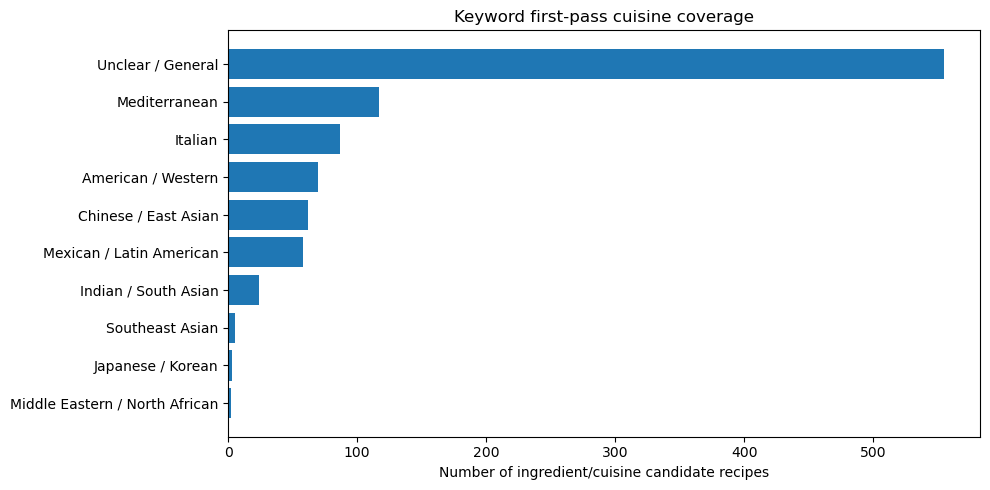

In [93]:
if "cuisine_summary" in globals() and cuisine_summary is not None:
    plot_df = cuisine_summary.sort_values("n_recipes")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(plot_df["cuisine_tag"].astype(str), plot_df["n_recipes"])
    ax.set_xlabel("Number of ingredient/cuisine candidate recipes")
    ax.set_title("Keyword first-pass cuisine coverage")
    plt.tight_layout()
    plt.show()
else:
    print("cuisine_summary is not available yet.")

save first pass

In [94]:
if "mvp_tagged" in globals() and mvp_tagged is not None:
    tagged_csv = OUT_DIR / "mvp_recipe_cuisine_tagged_candidates_keyword.csv"
    tagged_parquet = OUT_DIR / "mvp_recipe_cuisine_tagged_candidates_keyword.parquet"

    mvp_tagged.to_csv(tagged_csv, index=False)
    mvp_tagged.to_parquet(tagged_parquet, index=False)

    print("Wrote:", tagged_csv)
    print("Wrote:", tagged_parquet)
else:
    print("mvp_tagged is not available yet, so nothing was exported.")

Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\mvp_recipe_curation\mvp_recipe_cuisine_tagged_candidates_keyword.csv
Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\mvp_recipe_curation\mvp_recipe_cuisine_tagged_candidates_keyword.parquet


In [95]:
if "mvp_pool" in globals() and mvp_pool is not None:
    print("mvp_pool shape:", mvp_pool.shape)
    print("candidate_pool_rule:", candidate_pool_rule)
else:
    print("mvp_pool is not available.")

if "mvp_tagged" in globals() and mvp_tagged is not None:
    print("\nCuisine tag counts:")
    display(mvp_tagged["cuisine_tag"].value_counts(dropna=False))

    print("\nNeeds cuisine review counts:")
    display(mvp_tagged["needs_cuisine_review"].value_counts(dropna=False))
else:
    print("mvp_tagged is not available.")

mvp_pool shape: (983, 7)
candidate_pool_rule: ingredient-focused: has ingredient text and >=3 ingredient lines

Cuisine tag counts:


cuisine_tag
Unclear / General                 555
Mediterranean                     117
Italian                            87
American / Western                 70
Chinese / East Asian               62
Mexican / Latin American           58
Indian / South Asian               24
Southeast Asian                     5
Japanese / Korean                   3
Middle Eastern / North African      2
Name: count, dtype: int64


Needs cuisine review counts:


needs_cuisine_review
True     749
False    234
Name: count, dtype: int64

LLM Imports for locally hosted Qwen 3 14B

In [96]:
from openai import OpenAI
import time
from datetime import datetime

LM Studio Connect

In [97]:
client = OpenAI(
    base_url="http://localhost:1234/v1",
    api_key="lm-studio"
)

models = client.models.list()

print("Available models:")
for model in models.data:
    print(model.id)

Available models:
qwen/qwen3-14b
text-embedding-nomic-embed-text-v1.5


In [98]:
MODEL_NAME = models.data[0].id
print("Using model:", MODEL_NAME)

Using model: qwen/qwen3-14b


In [167]:
LLM_CUISINE_LABELS = [
    "American / General Western",
    "Southern / Cajun / Creole",
    "Italian",
    "Mexican / Tex-Mex",
    "Central / South American",
    "Caribbean",
    "Chinese",
    "Japanese",
    "Korean",
    "Southeast Asian",
    "Indian / South Asian",
    "Middle Eastern",
    "North African",
    "Mediterranean / Greek",
    "African",
    "European",
    "Fusion",
    "Unclear / General",
    "Other / Specific",
]

In [168]:
def build_llm_cuisine_prompt(row):
    labels_text = "\n".join(f"- {label}" for label in LLM_CUISINE_LABELS)

    title = str(row.get("title", ""))
    all_ingredients = str(row.get("all_ingredients", ""))
    ingredient_names = str(row.get("ingredient_names", ""))

    return f"""
/no_think

You are helping curate recipes for a nutrition-focused meal planning MVP.

Classify the likely cuisine, cultural origin, or regional food tradition of this recipe using the recipe title and ingredients.

Allowed broad cuisine labels:

{labels_text}

Return valid JSON only. Do not include markdown. Do not explain outside the JSON.

JSON schema:

{{
  "cuisine_tag": "one allowed broad cuisine label",
  "specific_cuisine": "best specific cuisine, country, region, or style if there is reasonable evidence; otherwise null",
  "confidence": 0.0,
  "reason": "one short sentence explaining the classification",
  "evidence_ingredients": ["ingredient 1", "ingredient 2"]
}}

Rules:
- Use only one cuisine_tag from the allowed list.
- Use the recipe title as evidence when it contains meaningful cuisine clues.
- Do not rely on the title alone if the ingredients contradict it.
- Ingredient combinations are stronger evidence than individual ingredients.
- Use "Indian / South Asian" for Indian, Pakistani, Bangladeshi, Sri Lankan, Nepali, or similar South Asian recipes.
- Use "Southeast Asian" for Thai, Vietnamese, Filipino, Indonesian, Malaysian, Cambodian, Lao, Burmese, or similar recipes.
- Use "Mexican / Tex-Mex" for Mexican, Tex-Mex, taco, enchilada, salsa, tortilla, chile-forward recipes.
- Use "Central / South American" for Peruvian, Brazilian, Colombian, Argentinian, Salvadoran, and similar recipes when not clearly Mexican/Tex-Mex.
- Use "Middle Eastern" for Lebanese, Syrian, Turkish, Persian/Iranian, Israeli, Palestinian, Iraqi, and similar recipes.
- Use "North African" for Moroccan, Egyptian, Tunisian, Algerian, Libyan, and similar recipes.
- Use "Mediterranean / Greek" for Greek or general Mediterranean recipes that are not clearly Italian, Middle Eastern, or North African.
- Use "European" for European recipes that do not fit Italian, Mediterranean/Greek, or another clearer label.
- Use "American / General Western" for generic U.S./Western recipes, casseroles, burgers, sandwiches, simple baked goods, or recipes without stronger cuisine evidence.
- Use "Southern / Cajun / Creole" for Southern US, Cajun, Creole, Louisiana, soul food, or similar recipes.
- Use "African" for Sub-Saharan African recipes such as Ethiopian, Nigerian, Ghanaian, Senegalese, Kenyan, or similar cuisines.
- For specific_cuisine, give a reasonable specific cuisine, country, region, or style when the title or ingredient combinations support it.
- Use null for specific_cuisine only when the ingredients and title are too generic.
- Examples of specific_cuisine: "Thai", "Vietnamese", "Punjabi", "South Indian", "Tex-Mex", "Cajun", "Greek", "Lebanese", "Moroccan", "Korean", "Japanese", "Italian-American".
- If evidence is weak, use "Unclear / General".
- If the recipe is clearly specific but does not fit the allowed labels, use "Other / Specific".
- Do not guess confidently from a single weak ingredient.
- Set confidence between 0.0 and 1.0.
- evidence_ingredients should list the ingredients or title terms that influenced the classification.

Recipe title:
{title}

Raw ingredient lines:
{all_ingredients}

Parsed ingredient names:
{ingredient_names}
""".strip()

JSON parser

In [169]:
def parse_llm_json(text):
    text = str(text).strip()

    # Remove common markdown wrappers
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    # Extract the first JSON object if the model adds extra text
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if match:
        text = match.group(0)

    return json.loads(text)

Single recipe test

In [139]:
test_row = mvp_pool.iloc[0]

prompt = build_llm_cuisine_prompt(test_row)

response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {
            "role": "system",
            "content": "You classify recipe cuisine from ingredients. Return valid JSON only."
        },
        {
            "role": "user",
            "content": prompt
        },
    ],
    temperature=0.1,
    max_tokens=400,
)

raw_text = response.choices[0].message.content

print(raw_text)

parsed = parse_llm_json(raw_text)
parsed



{
  "cuisine_tag": "American / Western",
  "specific_cuisine": null,
  "confidence": 0.85,
  "underrepresented_flag": false,
  "reason": "The ingredients commonly found in American potato salad, such as mayonnaise, pickles, shallot, and corn, support the classification.",
  "evidence_ingredients": ["mayonnaise", "kosher dill pickles", "shallot", "white wine vinegar", "corn"]
}


{'cuisine_tag': 'American / Western',
 'specific_cuisine': None,
 'confidence': 0.85,
 'underrepresented_flag': False,
 'reason': 'The ingredients commonly found in American potato salad, such as mayonnaise, pickles, shallot, and corn, support the classification.',
 'evidence_ingredients': ['mayonnaise',
  'kosher dill pickles',
  'shallot',
  'white wine vinegar',
  'corn']}

In [161]:
def tag_recipe_with_llm(row, model_name=MODEL_NAME, sleep_seconds=0.0):
    prompt = build_llm_cuisine_prompt(row)

    result = {
        "recipe_id": row["recipe_id"],
        "llm_model": model_name,
        "llm_ts": datetime.now().isoformat(timespec="seconds"),
        "llm_raw_response": None,
        "llm_error": None,
    }

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {
                    "role": "system",
                    "content": "You classify recipe cuisine from ingredients. Return valid JSON only."
                },
                {
                    "role": "user",
                    "content": prompt
                },
            ],
            temperature=0.1,
            max_tokens=400,
        )

        raw_text = response.choices[0].message.content
        result["llm_raw_response"] = raw_text

        parsed = parse_llm_json(raw_text)

        result.update({
            "llm_cuisine_tag": parsed.get("cuisine_tag"),
            "llm_specific_cuisine": (
                parsed.get("specific_cuisine")
                or parsed.get("specific_region")
                or parsed.get("specific_origin")
                or parsed.get("specific_style")
            ),
            "llm_confidence": parsed.get("confidence"),
            "llm_reason": parsed.get("reason"),
            "llm_evidence_ingredients": parsed.get("evidence_ingredients"),
        })

    except Exception as e:
        result["llm_error"] = repr(e)

    if sleep_seconds:
        time.sleep(sleep_seconds)

    return result

10 recipe test

In [170]:
test_sample = mvp_pool.head(10).copy()

llm_test_results = []

for i, (_, row) in enumerate(test_sample.iterrows(), start=1):
    print(f"Tagging {i}/{len(test_sample)} | recipe_id={row['recipe_id']}")
    llm_test_results.append(tag_recipe_with_llm(row))

llm_test_df = pd.DataFrame(llm_test_results)

display(
    llm_test_df[
        [
            "recipe_id",
            "llm_cuisine_tag",
            "llm_specific_cuisine",
            "llm_confidence",
            "llm_reason",
            "llm_error",
        ]
    ]
)

Tagging 1/10 | recipe_id=1702
Tagging 2/10 | recipe_id=2398
Tagging 3/10 | recipe_id=4827
Tagging 4/10 | recipe_id=7093
Tagging 5/10 | recipe_id=9040
Tagging 6/10 | recipe_id=11222
Tagging 7/10 | recipe_id=13611
Tagging 8/10 | recipe_id=14871
Tagging 9/10 | recipe_id=23256
Tagging 10/10 | recipe_id=24729


,recipe_id,llm_cuisine_tag,llm_specific_cuisine,llm_confidence,llm_reason,llm_error
0,1702,American / General Western,None,0.85,"The ingredients are common in American-style potato salad, including mayonnaise, pickles, shallot, and corn.",None
1,2398,American / General Western,None,0.85,"The ingredients are common in American snack mixes, including cereals, pretzels, and seasonings typically found in U.S. party foods.",None
2,4827,American / General Western,None,0.85,"The ingredients are commonly used in American candy recipes, with no strong cultural or regional indicators.",None
3,7093,American / General Western,None,0.65,"The ingredients suggest a simple, American-style stuffed mushroom recipe with common Western pantry items like bacon, cream cheese, and garlic powder.",None
4,9040,American / General Western,None,0.75,"The ingredients suggest a simple, Western-style dip commonly found in American cuisine, with no strong indicators of specific regional or ethnic influences.",None
5,11222,American / General Western,None,0.75,"The ingredients are common in American-style dressings, with no strong indicators of a specific regional or international cuisine.",None
6,13611,American / General Western,None,0.85,"The ingredients are common in American desserts, including Ritz crackers, cream cheese, and Dream Whip, which are typical of U.S.-style baked goods.",None
7,14871,American / General Western,None,0.75,The ingredients are common in American-style soups with no strong regional or cultural indicators.,None
8,23256,European,Ukrainian,0.90,"The recipe title explicitly mentions 'Ukranian Holubtsi,' which is a well-known Ukrainian dish, and the ingredients align with traditional Eastern European cooking methods.",None
9,24729,American / General Western,None,0.60,"The ingredients are common in general American baking, such as brown sugar, margarine, self-rising flour, and vanilla.",None


In [171]:
display(
    llm_test_df[
        [
            "recipe_id",
            "llm_cuisine_tag",
            "llm_specific_cuisine",
            "llm_confidence",
            "llm_reason",
            "llm_raw_response",
            "llm_error",
        ]
    ]
)

,recipe_id,llm_cuisine_tag,llm_specific_cuisine,llm_confidence,llm_reason,llm_raw_response,llm_error
0,1702,American / General Western,None,0.85,"The ingredients are common in American-style potato salad, including mayonnaise, pickles, shallot, and corn.","\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.85,\n ""reason"": ""The ingredients are common in American-style potato salad, including mayonnaise, pickles, shallot, and corn."",\n ""evidence_in...",None
1,2398,American / General Western,None,0.85,"The ingredients are common in American snack mixes, including cereals, pretzels, and seasonings typically found in U.S. party foods.","\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.85,\n ""reason"": ""The ingredients are common in American snack mixes, including cereals, pretzels, and seasonings typically found in U.S. party ...",None
2,4827,American / General Western,None,0.85,"The ingredients are commonly used in American candy recipes, with no strong cultural or regional indicators.","\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.85,\n ""reason"": ""The ingredients are commonly used in American candy recipes, with no strong cultural or regional indicators."",\n ""evidence_in...",None
3,7093,American / General Western,None,0.65,"The ingredients suggest a simple, American-style stuffed mushroom recipe with common Western pantry items like bacon, cream cheese, and garlic powder.","\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.65,\n ""reason"": ""The ingredients suggest a simple, American-style stuffed mushroom recipe with common Western pantry items like bacon, cream ch...",None
4,9040,American / General Western,None,0.75,"The ingredients suggest a simple, Western-style dip commonly found in American cuisine, with no strong indicators of specific regional or ethnic influences.","\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.75,\n ""reason"": ""The ingredients suggest a simple, Western-style dip commonly found in American cuisine, with no strong indicators of specific ...",None
5,11222,American / General Western,None,0.75,"The ingredients are common in American-style dressings, with no strong indicators of a specific regional or international cuisine.","\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.75,\n ""reason"": ""The ingredients are common in American-style dressings, with no strong indicators of a specific regional or international cuis...",None
6,13611,American / General Western,None,0.85,"The ingredients are common in American desserts, including Ritz crackers, cream cheese, and Dream Whip, which are typical of U.S.-style baked goods.","\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.85,\n ""reason"": ""The ingredients are common in American desserts, including Ritz crackers, cream cheese, and Dream Whip, which are typical of U...",None
7,14871,American / General Western,None,0.75,The ingredients are common in American-style soups with no strong regional or cultural indicators.,"\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.75,\n ""reason"": ""The ingredients are common in American-style soups with no strong regional or cultural indicators."",\n ""evidence_ingredients""...",None
8,23256,European,Ukrainian,0.90,"The recipe title explicitly mentions 'Ukranian Holubtsi,' which is a well-known Ukrainian dish, and the ingredients align with traditional Eastern European cooking methods.","\n\n{\n ""cuisine_tag"": ""European"",\n ""specific_cuisine"": ""Ukrainian"",\n ""confidence"": 0.9,\n ""reason"": ""The recipe title explicitly mentions 'Ukranian Holu

join test results back to ingredients

In [172]:
llm_test_review = mvp_pool.merge(llm_test_df, on="recipe_id", how="inner")

display(
    llm_test_review[
        [
            "recipe_id",
            "title",
            "all_ingredients",
            "ingredient_names",
            "llm_cuisine_tag",
            "llm_specific_cuisine",
            "llm_confidence",
            "llm_reason",
            "llm_error",
        ]
    ]
)

,recipe_id,title,all_ingredients,ingredient_names,llm_cuisine_tag,llm_specific_cuisine,llm_confidence,llm_reason,llm_error
0,1702,New Classic Potato Salad,"1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes | 1/4 c. mayonnaise | 1/4 c. chopped kosher dill pickles | 2 Tbsp. finely chopped shallot | 1 Tbsp white wine vinegar | 1/2 Tsp sugar | 1/2 Tsp salt | 1 Tsp olive oil | 1 cup frozen whole...",ready-to-cook red potatoes | mayonnaise | kosher dill pickles | shallot | white wine vinegar | sugar | salt | olive oil | frozen whole-kernel corn,American / General Western,None,0.85,"The ingredients are common in American-style potato salad, including mayonnaise, pickles, shallot, and corn.",None
1,2398,Party Mix,1 stick margarine | 1/2 tsp. garlic salt | 1/2 tsp. onion salt | 1 tsp. salt | 1 beef bouillon cube | 2 c. Cheerios | 2 c. Wheat Chex | 2 c. Rice Chex | 1 small box pretzels | mixed nuts,margarine | garlic salt | onion salt | salt | beef bouillon cubes | Cheerios | Wheat Chex | Rice Chex | pretzels | mixed nuts,American / General Western,None,0.85,"The ingredients are common in American snack mixes, including cereals, pretzels, and seasonings typically found in U.S. party foods.",None
2,4827,Caramel Candy,1 c. white sugar | 1 c. white or dark Karo syrup | 1/4 tsp. salt | 1 c. whipping cream,"white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream",American / General Western,None,0.85,"The ingredients are commonly used in American candy recipes, with no strong cultural or regional indicators.",None
3,7093,Easy Stuffed Mushrooms,"1 lb. large fresh mushrooms, stems removed | 6 bacon strips, fried crisp and crumbled | dash of garlic powder | 6 oz. cream cheese | 2 Tbsp. minced onion",fresh mushrooms | bacon strips | garlic powder | cream cheese | onion,American / General Western,None,0.65,"The ingredients suggest a simple, American-style stuffed mushroom recipe with common Western pantry items like bacon, cream cheese, and garlic powder.",None
4,9040,Rye Bread Dip(Good For Parties!),1 1/2 pt. sour cream | 3 tsp. parsley flakes | 2 tsp. Spice Islands Beau Monde seasoning | 1 1/2 pt. mayonnaise | 1/2 tsp. dill weed | 2 tsp. minced onion | 9 oz. pkg. shredded corned beef | 2 lb. round rye bread loaf (can be ordered from Kroger),"sour cream | parsley flakes | Spice Islands Beau Monde seasoning | mayonnaise | dill weed | onion | pkg., corned beef | round rye bread loaves",American / General Western,None,0.75,"The ingredients suggest a simple, Western-style dip commonly found in American cuisine, with no strong indicators of specific regional or ethnic influences.",None
5,11222,Bleu Cheese Dressing,"3/4 c. sour cream | 1/2 tsp. dry mustard | 1/2 tsp. black pepper | 1/2 tsp. salt | 1/2 tsp. garlic powder | 1 tsp. Worcestershire sauce | 1 1/3 c. mayonnaise | 4 oz. Bleu cheese, crumbled",sour cream | dry mustard | black pepper | salt | garlic powder | Worcestershire sauce | mayonnaise | Bleu cheese,American / General Western,None,0.75,"The ingredients are common in American-style dressings, with no strong indicators of a specific regional or international cuisine.",None
6,13611,Ritz Cracker Dessert,"6 egg whites, beaten stiff | 1 tsp. baking powder | 1 tsp. vanilla | 1 1/2 c. sugar | 1 c. pecans | 56 Ritz crackers, rolled fine | 2 pkg. Dream Whip | 1 large cream cheese | 1 can drained crushed pineapple","egg whites | baking powder | vanilla | sugar | pecans | Ritz crackers | pkg., Dream Whip | cream cheese | crushed pineapple",American / General Western,None,0.85,"The ingredients are common in American desserts, including Ritz crackers, cream cheese, and Dream Whip, which are typical of U.S.-style baked goods.",None
7,14871,Vegetable Beef Soup,"1 1/2 lb. lean ground chuck | 1 large onion, chopped | 1/2 green bell pepper, chopped | 6 potatoes, chopped and cooked | 1 (10 oz.) pkg. frozen whole kernel corn | 3 (16 oz.) cans mixed corn, okra and tomatoes | 1 (32 oz.) can tomato juice | Worc...","lean ground chuck | on

Load RecipeNLG to link title in tagging

In [173]:
recipe_nlg_path = ROOT / "Data" / "recipes" / "RecipeNLG.csv"

# Inspect columns without loading the full file
recipe_nlg_columns = pd.read_csv(recipe_nlg_path, nrows=0).columns.tolist()

print("RecipeNLG columns:")
print(recipe_nlg_columns)

# The first column appears to be the RecipeNLG ID/index that matches pipeline recipe_id
recipe_id_source_col = recipe_nlg_columns[0]

if "title" not in recipe_nlg_columns:
    raise ValueError("Could not find a 'title' column in RecipeNLG.csv")

print("Using ID column:", recipe_id_source_col)
print("Using title column: title")

recipe_meta = pd.read_csv(
    recipe_nlg_path,
    usecols=[recipe_id_source_col, "title"],
)

recipe_meta = recipe_meta.rename(columns={
    recipe_id_source_col: "recipe_id",
    "title": "real_title",
})

print(recipe_meta.shape)
display(recipe_meta.head())

RecipeNLG columns:
['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source', 'NER']
Using ID column: Unnamed: 0
Using title column: title
(2231142, 2)


,recipe_id,real_title
0,0,No-Bake Nut Cookies
1,1,Jewell Ball'S Chicken
2,2,Creamy Corn
3,3,Chicken Funny
4,4,Reeses Cups(Candy)


In [174]:
# Make join keys consistent
recipe_meta["recipe_id"] = recipe_meta["recipe_id"].astype(str)
mvp_pool["recipe_id"] = mvp_pool["recipe_id"].astype(str)

# Remove old title join columns if rerunning
for col in ["real_title"]:
    if col in mvp_pool.columns:
        mvp_pool = mvp_pool.drop(columns=[col])

# Join titles onto MVP pool
mvp_pool = mvp_pool.merge(
    recipe_meta[["recipe_id", "real_title"]],
    on="recipe_id",
    how="left"
)

# Replace placeholder titles with real RecipeNLG titles
mvp_pool["title"] = mvp_pool["real_title"].fillna(mvp_pool["title"])

print("Titles matched:", mvp_pool["real_title"].notna().sum(), "of", len(mvp_pool))

display(
    mvp_pool[
        ["recipe_id", "title", "real_title", "n_ingredient_lines", "ingredient_names"]
    ].head(20)
)

Titles matched: 983 of 983


,recipe_id,title,real_title,n_ingredient_lines,ingredient_names
0,1702,New Classic Potato Salad,New Classic Potato Salad,9,ready-to-cook red potatoes | mayonnaise | kosher dill pickles | shallot | white wine vinegar | sugar | salt | olive oil | frozen whole-kernel corn
1,2398,Party Mix,Party Mix,10,margarine | garlic salt | onion salt | salt | beef bouillon cubes | Cheerios | Wheat Chex | Rice Chex | pretzels | mixed nuts
2,4827,Caramel Candy,Caramel Candy,4,"white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream"
3,7093,Easy Stuffed Mushrooms,Easy Stuffed Mushrooms,5,fresh mushrooms | bacon strips | garlic powder | cream cheese | onion
4,9040,Rye Bread Dip(Good For Parties!),Rye Bread Dip(Good For Parties!),8,"sour cream | parsley flakes | Spice Islands Beau Monde seasoning | mayonnaise | dill weed | onion | pkg., corned beef | round rye bread loaves"
5,11222,Bleu Cheese Dressing,Bleu Cheese Dressing,8,sour cream | dry mustard | black pepper | salt | garlic powder | Worcestershire sauce | mayonnaise | Bleu cheese
6,13611,Ritz Cracker Dessert,Ritz Cracker Dessert,9,"egg whites | baking powder | vanilla | sugar | pecans | Ritz crackers | pkg., Dream Whip | cream cheese | crushed pineapple"
7,14871,Vegetable Beef Soup,Vegetable Beef Soup,9,"lean ground chuck | onion | green bell pepper | potatoes | pkg. frozen whole kernel corn | mixed corn, okra and tomatoes | tomato juice | Worcestershire sauce | garlic salt, salt, pepper"
8,23256,"Ukranian ""Holubtsi""(Stuffed Cabbage Rolls)","Ukranian ""Holubtsi""(Stuffed Cabbage Rolls)",8,"cabbage | mushrooms | onions | raw ground beef | cooking oil | rice | tomato juice | salt, pepper"
9,24729,Congo Bar,Congo Bar,6,light brown sugar | margarine | self-rising flour | eggs | nuts | vanilla


In [175]:
mvp_pool["ingredient_context"] = (
    "Recipe title: "
    + mvp_pool["title"].astype(str)
    + " | Raw ingredient lines: "
    + mvp_pool["all_ingredients"].astype(str)
    + " | Parsed ingredient names: "
    + mvp_pool["ingredient_names"].astype(str)
)

display(
    mvp_pool[
        ["recipe_id", "title", "ingredient_context"]
    ].head(10)
)

,recipe_id,title,ingredient_context
0,1702,New Classic Potato Salad,"Recipe title: New Classic Potato Salad | Raw ingredient lines: 1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes | 1/4 c. mayonnaise | 1/4 c. chopped kosher dill pickles | 2 Tbsp. finely chopped shallot | 1 Tbsp white wine vinegar | 1/2 ..."
1,2398,Party Mix,Recipe title: Party Mix | Raw ingredient lines: 1 stick margarine | 1/2 tsp. garlic salt | 1/2 tsp. onion salt | 1 tsp. salt | 1 beef bouillon cube | 2 c. Cheerios | 2 c. Wheat Chex | 2 c. Rice Chex | 1 small box pretzels | mixed nuts | Parsed in...
2,4827,Caramel Candy,"Recipe title: Caramel Candy | Raw ingredient lines: 1 c. white sugar | 1 c. white or dark Karo syrup | 1/4 tsp. salt | 1 c. whipping cream | Parsed ingredient names: white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream"
3,7093,Easy Stuffed Mushrooms,"Recipe title: Easy Stuffed Mushrooms | Raw ingredient lines: 1 lb. large fresh mushrooms, stems removed | 6 bacon strips, fried crisp and crumbled | dash of garlic powder | 6 oz. cream cheese | 2 Tbsp. minced onion | Parsed ingredient names: fres..."
4,9040,Rye Bread Dip(Good For Parties!),Recipe title: Rye Bread Dip(Good For Parties!) | Raw ingredient lines: 1 1/2 pt. sour cream | 3 tsp. parsley flakes | 2 tsp. Spice Islands Beau Monde seasoning | 1 1/2 pt. mayonnaise | 1/2 tsp. dill weed | 2 tsp. minced onion | 9 oz. pkg. shred...
5,11222,Bleu Cheese Dressing,"Recipe title: Bleu Cheese Dressing | Raw ingredient lines: 3/4 c. sour cream | 1/2 tsp. dry mustard | 1/2 tsp. black pepper | 1/2 tsp. salt | 1/2 tsp. garlic powder | 1 tsp. Worcestershire sauce | 1 1/3 c. mayonnaise | 4 oz. Bleu cheese, crumbled..."
6,13611,Ritz Cracker Dessert,"Recipe title: Ritz Cracker Dessert | Raw ingredient lines: 6 egg whites, beaten stiff | 1 tsp. baking powder | 1 tsp. vanilla | 1 1/2 c. sugar | 1 c. pecans | 56 Ritz crackers, rolled fine | 2 pkg. Dream Whip | 1 large cream cheese | 1 can draine..."
7,14871,Vegetable Beef Soup,"Recipe title: Vegetable Beef Soup | Raw ingredient lines: 1 1/2 lb. lean ground chuck | 1 large onion, chopped | 1/2 green bell pepper, chopped | 6 potatoes, chopped and cooked | 1 (10 oz.) pkg. frozen whole kernel corn | 3 (16 oz.) cans mixed co..."
8,23256,"Ukranian ""Holubtsi""(Stuffed Cabbage Rolls)","Recipe title: Ukranian ""Holubtsi""(Stuffed Cabbage Rolls) | Raw ingredient lines: 3 lb. head cabbage | 1 c. sliced mushrooms | 1 c. chopped onions | 1 lb. raw ground beef | 3 Tbsp. cooking oil | 2 c. cooked rice (white or brown), cooked accordin..."
9,24729,Congo Bar,Recipe title: Congo Bar | Raw ingredient lines: 1 lb. box light brown sugar | 1 1/4 sticks margarine | 2 3/4 c. self-rising flour | 3 eggs | 1 c. chopped nuts | 1 tsp. vanilla | Parsed ingredient names: light brown sugar | margarine | self-rising...


Full LLM Tagging

In [177]:
LLM_OUT_PATH = OUT_DIR / "mvp_recipe_llm_cuisine_tags_with_titles_checkpoint_v2.csv"

# Resume from checkpoint if it exists
if LLM_OUT_PATH.exists():
    completed_llm_tags = pd.read_csv(LLM_OUT_PATH)
    completed_ids = set(completed_llm_tags["recipe_id"].astype(str))
    llm_results = completed_llm_tags.to_dict("records")
    print(f"Loaded checkpoint with {len(completed_ids):,} completed recipes.")
else:
    completed_ids = set()
    llm_results = []
    print("No checkpoint found. Starting fresh.")

rows_to_tag = mvp_pool.loc[
    ~mvp_pool["recipe_id"].astype(str).isin(completed_ids)
].copy()

print(f"Rows remaining to tag: {len(rows_to_tag):,}")

for i, (_, row) in enumerate(rows_to_tag.iterrows(), start=1):
    print(f"Tagging {i}/{len(rows_to_tag)} | recipe_id={row['recipe_id']}")

    result = tag_recipe_with_llm(row)
    llm_results.append(result)

    # Save every 25 recipes
    if i % 25 == 0:
        pd.DataFrame(llm_results).to_csv(LLM_OUT_PATH, index=False)
        print("Checkpoint saved:", LLM_OUT_PATH)

# Final save
llm_tags_df = pd.DataFrame(llm_results)
llm_tags_df.to_csv(LLM_OUT_PATH, index=False)

print("Final checkpoint saved:", LLM_OUT_PATH)
display(llm_tags_df.head())

No checkpoint found. Starting fresh.
Rows remaining to tag: 983
Tagging 1/983 | recipe_id=1702
Tagging 2/983 | recipe_id=2398
Tagging 3/983 | recipe_id=4827
Tagging 4/983 | recipe_id=7093
Tagging 5/983 | recipe_id=9040
Tagging 6/983 | recipe_id=11222
Tagging 7/983 | recipe_id=13611
Tagging 8/983 | recipe_id=14871
Tagging 9/983 | recipe_id=23256
Tagging 10/983 | recipe_id=24729
Tagging 11/983 | recipe_id=27257
Tagging 12/983 | recipe_id=30160
Tagging 13/983 | recipe_id=32812
Tagging 14/983 | recipe_id=39071
Tagging 15/983 | recipe_id=39415
Tagging 16/983 | recipe_id=40557
Tagging 17/983 | recipe_id=42576
Tagging 18/983 | recipe_id=48154
Tagging 19/983 | recipe_id=51444
Tagging 20/983 | recipe_id=53066
Tagging 21/983 | recipe_id=57354
Tagging 22/983 | recipe_id=58379
Tagging 23/983 | recipe_id=59342
Tagging 24/983 | recipe_id=61898
Tagging 25/983 | recipe_id=64372
Checkpoint saved: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\mvp_recipe_curation\mvp_recipe_llm_cuisine_ta

,recipe_id,llm_model,llm_ts,llm_raw_response,llm_error,llm_cuisine_tag,llm_specific_cuisine,llm_confidence,llm_reason,llm_evidence_ingredients
0,1702,qwen/qwen3-14b,2026-06-14T20:12:30,"\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.85,\n ""reason"": ""The ingredients are common in American-style potato salad, with mayonnaise, pickles, and corn being typical components."",\n ""...",None,American / General Western,None,0.85,"The ingredients are common in American-style potato salad, with mayonnaise, pickles, and corn being typical components.","[mayonnaise, kosher dill pickles, white wine vinegar, frozen whole-kernel corn]"
1,2398,qwen/qwen3-14b,2026-06-14T20:12:33,"\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.85,\n ""reason"": ""The ingredients are common in American snack mixes, including cereals, pretzels, nuts, and seasonings typically found in U.S. ...",None,American / General Western,None,0.85,"The ingredients are common in American snack mixes, including cereals, pretzels, nuts, and seasonings typically found in U.S. party foods.","[Cheerios, Wheat Chex, Rice Chex, pretzels, mixed nuts]"
2,4827,qwen/qwen3-14b,2026-06-14T20:12:35,"\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.85,\n ""reason"": ""The ingredients are commonly used in American candy recipes, particularly caramel-based sweets."",\n ""evidence_ingredients"": [...",None,American / General Western,None,0.85,"The ingredients are commonly used in American candy recipes, particularly caramel-based sweets.","[white sugar, Karo syrup, whipping cream]"
3,7093,qwen/qwen3-14b,2026-06-14T20:12:36,"\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.65,\n ""reason"": ""The ingredients are common in American comfort food, with no strong indicators of a specific international cuisine."",\n ""evid...",None,American / General Western,None,0.65,"The ingredients are common in American comfort food, with no strong indicators of a specific international cuisine.","[bacon strips, cream cheese]"
4,9040,qwen/qwen3-14b,2026-06-14T20:12:37,"\n\n{\n ""cuisine_tag"": ""American / General Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.75,\n ""reason"": ""The ingredients suggest a simple, party-friendly dip commonly found in American cuisine, with no strong regional or cultural i...",None,American / General Western,None,0.75,"The ingredients suggest a simple, party-friendly dip commonly found in American cuisine, with no strong regional or cultural indicators.","[sour cream, mayonnaise, corned beef, rye bread]"


Combine keyword + LLM tags

In [178]:
llm_tags_df = pd.read_csv(LLM_OUT_PATH)

# Make recipe_id the same type on both sides before merging
mvp_pool = mvp_pool.copy()
llm_tags_df = llm_tags_df.copy()

mvp_pool["recipe_id"] = mvp_pool["recipe_id"].astype(str)
llm_tags_df["recipe_id"] = llm_tags_df["recipe_id"].astype(str)

mvp_llm_tagged = mvp_pool.merge(llm_tags_df, on="recipe_id", how="left")

mvp_llm_tagged["llm_confidence"] = pd.to_numeric(
    mvp_llm_tagged["llm_confidence"],
    errors="coerce"
)

mvp_llm_tagged["llm_needs_review"] = (
    mvp_llm_tagged["llm_error"].notna()
    | mvp_llm_tagged["llm_cuisine_tag"].isna()
    | (mvp_llm_tagged["llm_confidence"].fillna(0) < 0.65)
    | mvp_llm_tagged["llm_cuisine_tag"].isin(["Unclear / General", "Other / Specific"])
)

display(
    mvp_llm_tagged[
        [
            "recipe_id",
            "title",
            "n_ingredient_lines",
            "llm_cuisine_tag",
            "llm_specific_cuisine",
            "llm_confidence",
            "llm_needs_review",
            "llm_reason",
            "ingredient_names",
        ]
    ].head(30)
)

,recipe_id,title,n_ingredient_lines,llm_cuisine_tag,llm_specific_cuisine,llm_confidence,llm_needs_review,llm_reason,ingredient_names
0,1702,New Classic Potato Salad,9,American / General Western,NaN,0.85,False,"The ingredients are common in American-style potato salad, with mayonnaise, pickles, and corn being typical components.",ready-to-cook red potatoes | mayonnaise | kosher dill pickles | shallot | white wine vinegar | sugar | salt | olive oil | frozen whole-kernel corn
1,2398,Party Mix,10,American / General Western,NaN,0.85,False,"The ingredients are common in American snack mixes, including cereals, pretzels, nuts, and seasonings typically found in U.S. party foods.",margarine | garlic salt | onion salt | salt | beef bouillon cubes | Cheerios | Wheat Chex | Rice Chex | pretzels | mixed nuts
2,4827,Caramel Candy,4,American / General Western,NaN,0.85,False,"The ingredients are commonly used in American candy recipes, particularly caramel-based sweets.","white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream"
3,7093,Easy Stuffed Mushrooms,5,American / General Western,NaN,0.65,False,"The ingredients are common in American comfort food, with no strong indicators of a specific international cuisine.",fresh mushrooms | bacon strips | garlic powder | cream cheese | onion
4,9040,Rye Bread Dip(Good For Parties!),8,American / General Western,NaN,0.75,False,"The ingredients suggest a simple, party-friendly dip commonly found in American cuisine, with no strong regional or cultural indicators.","sour cream | parsley flakes | Spice Islands Beau Monde seasoning | mayonnaise | dill weed | onion | pkg., corned beef | round rye bread loaves"
5,11222,Bleu Cheese Dressing,8,American / General Western,NaN,0.85,False,"The ingredients are common in American-style dressings, with no strong indicators of a specific regional or international cuisine.",sour cream | dry mustard | black pepper | salt | garlic powder | Worcestershire sauce | mayonnaise | Bleu cheese
6,13611,Ritz Cracker Dessert,9,American / General Western,NaN,0.85,False,"The ingredients are common in American desserts, including Ritz crackers, cream cheese, and crushed pineapple, which are frequently used in U.S.-style baked goods and no-bake desserts.","egg whites | baking powder | vanilla | sugar | pecans | Ritz crackers | pkg., Dream Whip | cream cheese | crushed pineapple"
7,14871,Vegetable Beef Soup,9,American / General Western,NaN,0.75,False,The ingredients are common in American-style soups with a focus on hearty vegetables and beef.,"lean ground chuck | onion | green bell pepper | potatoes | pkg. frozen whole kernel corn | mixed corn, okra and tomatoes | tomato juice | Worcestershire sauce | garlic salt, salt, pepper"
8,23256,"Ukranian ""Holubtsi""(Stuffed Cabbage Rolls)",8,European,Ukrainian,0.90,False,"The recipe title explicitly mentions 'Ukranian Holubtsi,' which is a traditional Ukrainian dish of stuffed cabbage rolls.","cabbage | mushrooms | onions | raw ground beef | cooking oil | rice | tomato juice | salt, pepper"
9,24729,Congo Bar,6,American / General Western,NaN,0.60,True,"The ingredients are common in general American baking, such as brown sugar, margarine, self-rising flour, eggs, nuts, and vanilla.",light brown sugar | margarine | self-rising flour | eggs | nuts | vanilla


Save LLM-tagged dataset

In [179]:
final_llm_csv = OUT_DIR / "mvp_recipe_llm_cuisine_tagged_candidates.csv"
final_llm_parquet = OUT_DIR / "mvp_recipe_llm_cuisine_tagged_candidates.parquet"

mvp_llm_tagged.to_csv(final_llm_csv, index=False)
mvp_llm_tagged.to_parquet(final_llm_parquet, index=False)

print("Wrote:", final_llm_csv)
print("Wrote:", final_llm_parquet)

Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\mvp_recipe_curation\mvp_recipe_llm_cuisine_tagged_candidates.csv
Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\mvp_recipe_curation\mvp_recipe_llm_cuisine_tagged_candidates.parquet


Summarize cuisine coverage

In [180]:
llm_cuisine_summary = (
    mvp_llm_tagged
    .groupby("llm_cuisine_tag", dropna=False)
    .agg(
        n_recipes=("recipe_id", "count"),
        avg_confidence=("llm_confidence", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        review_needed=("llm_needs_review", "sum"),
    )
    .reset_index()
    .sort_values("n_recipes", ascending=False)
)

display(llm_cuisine_summary)

,llm_cuisine_tag,n_recipes,avg_confidence,review_needed
1,American / General Western,672,0.747768,64
22,Unclear / General,51,0.256863,51
8,European,50,0.704000,13
15,Mediterranean / Greek,50,0.778000,0
16,Mexican / Tex-Mex,44,0.865909,0
12,Italian,28,0.894643,0
11,Indian / South Asian,21,0.816667,0
20,Southeast Asian,12,0.875000,0
21,Southern / Cajun / Creole,11,0.895455,0
13,Japanese,8,0.881250,0


In [152]:
# Prepare LLM-tagged results for visualization

if "mvp_llm_tagged" in globals() and mvp_llm_tagged is not None:
    graph_df = mvp_llm_tagged.copy()

elif "llm_tags_df" in globals() and llm_tags_df is not None:
    graph_df = llm_tags_df.copy()

else:
    raise ValueError("No LLM-tagged dataframe found. Expected mvp_llm_tagged or llm_tags_df.")

graph_df["llm_cuisine_tag"] = graph_df["llm_cuisine_tag"].fillna("Missing / Error")
graph_df["llm_confidence"] = pd.to_numeric(graph_df["llm_confidence"], errors="coerce")

print(f"Rows available for graphing: {len(graph_df):,}")
display(graph_df.head())

Rows available for graphing: 983


,recipe_id,n_ingredient_lines,all_ingredients,ingredient_names,title,ingredient_context,has_ingredients,real_title,llm_model,llm_ts,llm_raw_response,llm_error,llm_cuisine_tag,llm_specific_cuisine,llm_confidence,llm_underrepresented_flag,llm_reason,llm_evidence_ingredients,llm_needs_review
0,1702,9,"1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes | 1/4 c. mayonnaise | 1/4 c. chopped kosher dill pickles | 2 Tbsp. finely chopped shallot | 1 Tbsp white wine vinegar | 1/2 Tsp sugar | 1/2 Tsp salt | 1 Tsp olive oil | 1 cup frozen whole...",ready-to-cook red potatoes | mayonnaise | kosher dill pickles | shallot | white wine vinegar | sugar | salt | olive oil | frozen whole-kernel corn,New Classic Potato Salad,"Recipe title: New Classic Potato Salad | Raw ingredient lines: 1 bag (1 1/2 lb.) refrigerated, ready-to-cook red potatoes | 1/4 c. mayonnaise | 1/4 c. chopped kosher dill pickles | 2 Tbsp. finely chopped shallot | 1 Tbsp white wine vinegar | 1/2 ...",True,New Classic Potato Salad,qwen/qwen3-14b,2026-06-14T19:21:54,"\n\n{\n ""cuisine_tag"": ""American / Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.85,\n ""underrepresented_flag"": false,\n ""reason"": ""The ingredients commonly found in American potato salad, such as mayonnaise, pickles, shallot, and ...",NaN,American / Western,NaN,0.85,False,"The ingredients commonly found in American potato salad, such as mayonnaise, pickles, shallot, and corn, support the classification.","['mayonnaise', 'kosher dill pickles', 'shallot', 'white wine vinegar', 'corn']",False
1,2398,10,1 stick margarine | 1/2 tsp. garlic salt | 1/2 tsp. onion salt | 1 tsp. salt | 1 beef bouillon cube | 2 c. Cheerios | 2 c. Wheat Chex | 2 c. Rice Chex | 1 small box pretzels | mixed nuts,margarine | garlic salt | onion salt | salt | beef bouillon cubes | Cheerios | Wheat Chex | Rice Chex | pretzels | mixed nuts,Party Mix,Recipe title: Party Mix | Raw ingredient lines: 1 stick margarine | 1/2 tsp. garlic salt | 1/2 tsp. onion salt | 1 tsp. salt | 1 beef bouillon cube | 2 c. Cheerios | 2 c. Wheat Chex | 2 c. Rice Chex | 1 small box pretzels | mixed nuts | Parsed in...,True,Party Mix,qwen/qwen3-14b,2026-06-14T19:21:58,"\n\n{\n ""cuisine_tag"": ""American / Western"",\n ""specific_cuisine"": null,\n ""confidence"": 0.75,\n ""underrepresented_flag"": false,\n ""reason"": ""The ingredients are commonly found in American snack mixes, such as Cheerios, Wheat Chex, Rice Chex...",NaN,American / Western,NaN,0.75,False,"The ingredients are commonly found in American snack mixes, such as Cheerios, Wheat Chex, Rice Chex, pretzels, and mixed nuts.","['Cheerios', 'Wheat Chex', 'Rice Chex', 'pretzels', 'mixed nuts']",False
2,4827,4,1 c. white sugar | 1 c. white or dark Karo syrup | 1/4 tsp. salt | 1 c. whipping cream,"white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream",Caramel Candy,"Recipe title: Caramel Candy | Raw ingredient lines: 1 c. white sugar | 1 c. white or dark Karo syrup | 1/4 tsp. salt | 1 c. whipping cream | Parsed ingredient names: white sugar | white Karo syrup, dark Karo syrup | salt | whipping cream",True,Caramel Candy,qwen/qwen3-14b,2026-06-14T19:22:00,"\n\n{\n ""cuisine_tag"": ""Unclear / General"",\n ""specific_cuisine"": null,\n ""confidence"": 0.2,\n ""underrepresented_flag"": false,\n ""reason"": ""The ingredients are common in many cuisines and do not strongly indicate a specific cultural origin.""...",NaN,Unclear / General,NaN,0.20,False,The ingredients are common in many cuisines and do not strongly indicate a specific cultural origin.,"['white sugar', 'white Karo syrup', 'dark Karo syrup', 'whipping cream']",True
3,7093,5,"1 lb. large fresh mushrooms, stems removed | 6 bacon strips, fried crisp and crumbled | dash of garlic powder | 6 oz. cream cheese | 2 Tbsp. minced onion",fresh mushrooms | bacon strips | garlic powder | cream cheese | onion,Easy Stuffed Mushrooms,"Recipe title: Easy Stuffed Mushrooms | Raw ingredient lines: 1 lb. large fresh mushrooms, 

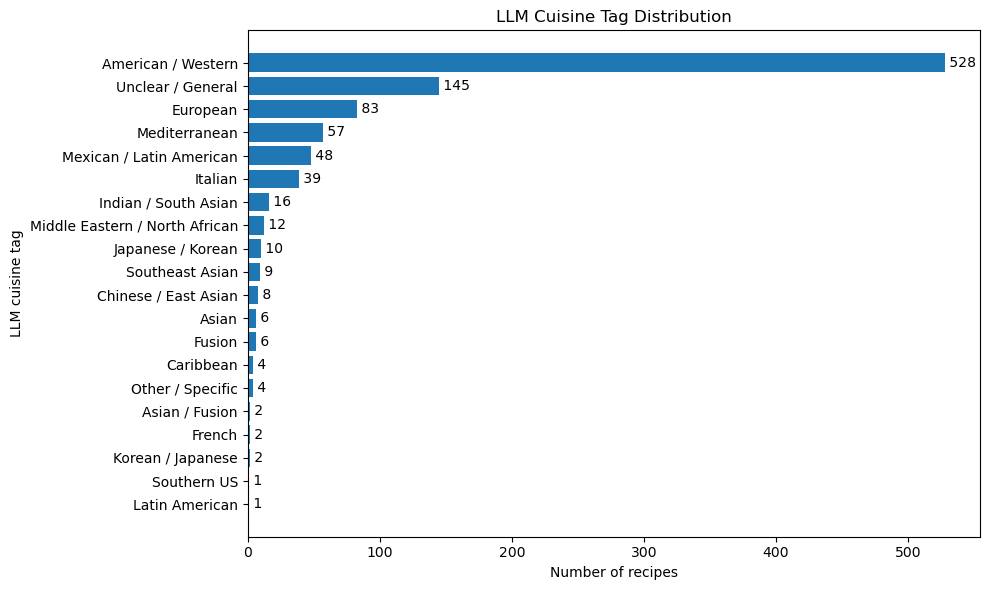

In [153]:
cuisine_counts = (
    graph_df["llm_cuisine_tag"]
    .value_counts(dropna=False)
    .reset_index()
)

cuisine_counts.columns = ["llm_cuisine_tag", "n_recipes"]
cuisine_counts = cuisine_counts.sort_values("n_recipes", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(cuisine_counts["llm_cuisine_tag"], cuisine_counts["n_recipes"])

ax.set_xlabel("Number of recipes")
ax.set_ylabel("LLM cuisine tag")
ax.set_title("LLM Cuisine Tag Distribution")

for i, value in enumerate(cuisine_counts["n_recipes"]):
    ax.text(value, i, f" {value}", va="center")

plt.tight_layout()
plt.show()

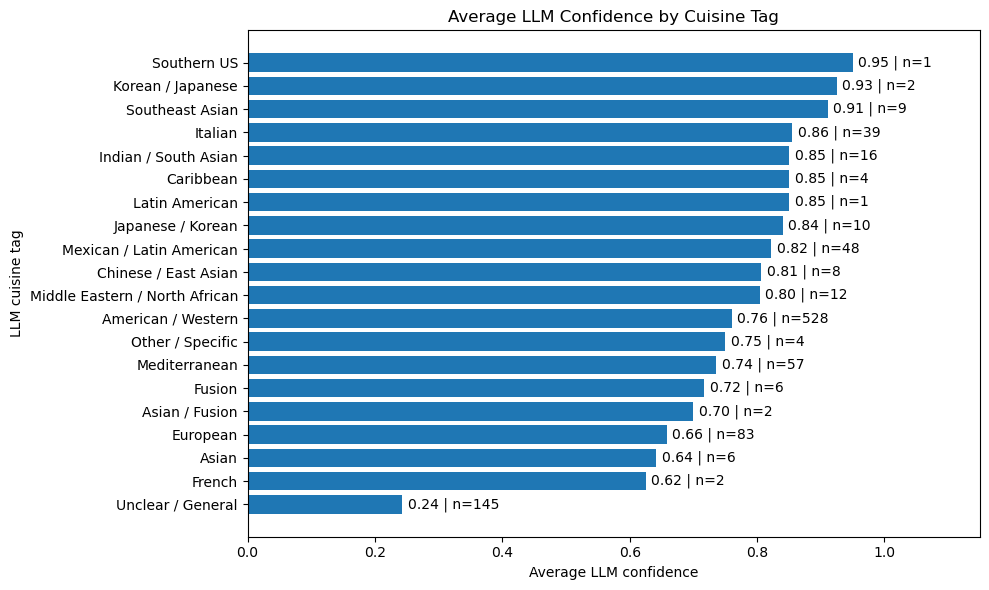

In [181]:
confidence_by_cuisine = (
    graph_df
    .groupby("llm_cuisine_tag", dropna=False)
    .agg(
        avg_confidence=("llm_confidence", "mean"),
        n_recipes=("recipe_id", "count")
    )
    .reset_index()
    .sort_values("avg_confidence", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    confidence_by_cuisine["llm_cuisine_tag"],
    confidence_by_cuisine["avg_confidence"]
)

ax.set_xlabel("Average LLM confidence")
ax.set_ylabel("LLM cuisine tag")
ax.set_title("Average LLM Confidence by Cuisine Tag")
ax.set_xlim(0, 1.15)

labels = [
    f"{row.avg_confidence:.2f} | n={int(row.n_recipes)}"
    for row in confidence_by_cuisine.itertuples()
]

ax.bar_label(
    bars,
    labels=labels,
    padding=4
)

plt.tight_layout()
plt.show()

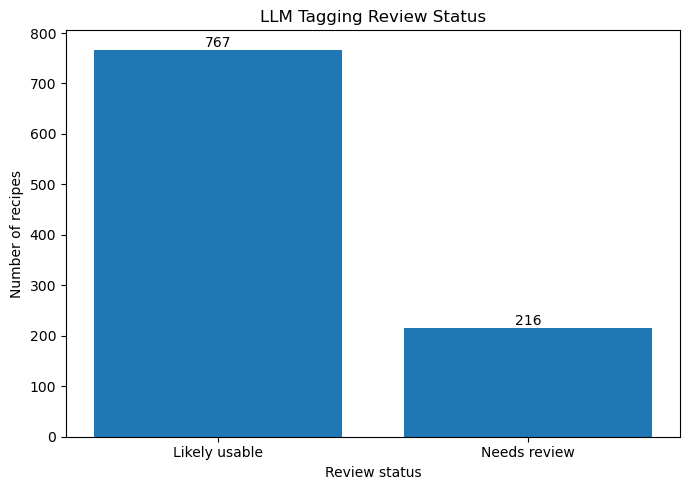

In [182]:
if "llm_needs_review" in graph_df.columns:
    review_counts = (
        graph_df["llm_needs_review"]
        .fillna(True)
        .value_counts()
        .reset_index()
    )

    review_counts.columns = ["llm_needs_review", "n_recipes"]
    review_counts["review_status"] = review_counts["llm_needs_review"].map({
        True: "Needs review",
        False: "Likely usable"
    })

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.bar(review_counts["review_status"], review_counts["n_recipes"])

    ax.set_xlabel("Review status")
    ax.set_ylabel("Number of recipes")
    ax.set_title("LLM Tagging Review Status")

    for i, value in enumerate(review_counts["n_recipes"]):
        ax.text(i, value, str(value), ha="center", va="bottom")

    plt.tight_layout()
    plt.show()
else:
    print("llm_needs_review column not found.")

In [183]:
# Print / display recipes that need LLM cuisine review

if "mvp_llm_tagged" in globals() and mvp_llm_tagged is not None:
    review_df = mvp_llm_tagged.copy()
elif "graph_df" in globals() and graph_df is not None:
    review_df = graph_df.copy()
else:
    raise ValueError("No LLM-tagged dataframe found. Expected mvp_llm_tagged or graph_df.")

# Make sure confidence is numeric
review_df["llm_confidence"] = pd.to_numeric(review_df["llm_confidence"], errors="coerce")

# Create review flag if it does not already exist
if "llm_needs_review" not in review_df.columns:
    review_df["llm_needs_review"] = (
        review_df["llm_error"].notna()
        | review_df["llm_cuisine_tag"].isna()
        | (review_df["llm_confidence"].fillna(0) < 0.65)
        | review_df["llm_cuisine_tag"].isin(["Unclear / General", "Other / Specific"])
    )

needs_review = review_df.loc[review_df["llm_needs_review"] == True].copy()

print(f"Recipes needing review: {len(needs_review):,}")

display(
    needs_review[
        [c for c in [
            "recipe_id",
            "title",
            "llm_cuisine_tag",
            "llm_specific_cuisine",
            "llm_confidence",
            "llm_reason",
            "llm_error",
            "ingredient_names",
            "all_ingredients",
        ] if c in needs_review.columns]
    ].sort_values(["llm_confidence", "llm_cuisine_tag"], ascending=[True, True])
)

Recipes needing review: 136


,recipe_id,title,llm_cuisine_tag,llm_specific_cuisine,llm_confidence,llm_reason,llm_error,ingredient_names,all_ingredients
39,111299,Stain Remover,Unclear / General,NaN,0.10,The ingredients are cleaning products and not related to any specific cuisine or food tradition.,NaN,detergent | bleach | boiling water,1/2 c. dishwasher detergent | 1/4 c. bleach | 1 gal. boiling water
64,175442,Miami Ice Cooler,Unclear / General,NaN,0.20,"The ingredients are primarily fruit-based and sweetened with artificial sweetener, lacking strong cultural or regional indicators.",NaN,"unsweetened orange juice | pineapple chunks in their own juice | chilled Glucerna Shakes Vanilla | artificial sweetener | coconut extract | frozen, unsweetened strawberries | ice cubes","1/2 cup unsweetened orange juice | 1 cup pineapple chunks in their own juice | 1 (8 oz.) can chilled Glucerna Shake Vanilla | 1 packet artificial sweetener | 1 tsp. coconut extract | 1 cup frozen, unsweetened strawberries | 5 ice cubes"
67,184913,Homemade Ribbon,Unclear / General,NaN,0.20,The ingredients are non-food items and do not indicate any specific cuisine or cultural origin.,NaN,cornstarch | water | Elmer's glue,1 Tbsp. cornstarch | 1 Tbsp. water | 1 Tbsp. Elmer's glue
87,234620,Cranberry Daiquiris,Unclear / General,NaN,0.20,The ingredients are primarily alcoholic and fruit-based with no strong cultural or regional indicators.,NaN,"frozen cranberry juice, cocktail | lemon juice | vodka, rum | banana | ice",6 oz. frozen cranberry juice or cocktail | 1/3 c. lemon juice | 6 to 8 oz. vodka or rum | 1 banana | 3 c. chopped ice
120,299483,Party Punch,Unclear / General,NaN,0.20,The ingredients are common in general Western or American recipes but do not strongly indicate a specific cuisine.,NaN,"sugar | water | frozen orange juice | pineapple juice | pkg., lemon jello | almond extract",6 c. sugar | 4 c. water | 1 (6 oz.) frozen orange juice | 2 cans pineapple juice (46 oz. size) | 4 pkg. lemon jello | 1 bottle almond extract | 1 gal. water
...,...,...,...,...,...,...,...,...,...
931,2073568,Pampushky,European,NaN,0.60,"The ingredients suggest a baked good, possibly similar to European pastries or breads, but there is not enough specific evidence to identify a particular cuisine.",NaN,"sugar | yeast, active dry | milk | flour | butter | eggs | egg yolks | vanilla extract","2 tablespoons sugar | 2 packages yeast, active dry | 1/4 cup milk | 5 cups flour, all-purpose | 1/4 pound butter | 1/2 cup sugar | 2 large eggs | 3 large egg yolks | 1 teaspoon vanilla extract"
409,975850,"Fet-Ta (Yemeni Bread ""Pudding"")",Middle Eastern,NaN,0.60,"The use of ghee and the name 'Fet-Ta' suggest a Middle Eastern influence, though the ingredients are not specific enough to identify a particular country or region.",NaN,tortillas | milk | ghee | sugar,"2 tortillas, torn into small pieces | 3/4 cup milk | 2 teaspoons ghee | 1 tablespoon sugar or 1 tablespoon honey"
826,1854844,Soy/Ginger Sauce Rack of Lamb,Other / Specific,NaN,0.60,"The use of soy sauce, mirin, ginger, and chili paste suggests Asian influence, but the combination with Worcestershire sauce, ketchup, honey, pomegranate juice, and lamb indicates a fusion or Western adaptation.",NaN,Worcestershire sauce | mirin | soy sauce | ginger | ketchup | garlic | shallot | honey | pomegranate juice | lemon juice | chili paste | black pepper | lamb racks,"14 cup Worcestershire sauce | 14 cup mirin | 12 cup soy sauce | 1 inch ginger, thinly sliced,smashed | 2 tablespoons ketchup | 14 cup chopped garlic | 14 cup chopped shallot | 12 cup honey | 12 cup pomegranate juice | 2 tablespoons lemon juice | ..."
45,121738,Leche Flan,Other / Specific,Spanish / Latin American,0.75,"Leche flan is a well-known dessert in Spanish and Latin American cuisines, commonly made with eggs, milk, sugar, and sometimes coconut.",NaN,brown sugar | water | heavy coconut | milk | eggs | lemon rind | white sugar,1/2 c. brown sugar | 1/8 c. water | 1 c. heavy coconut | milk | 3 eggs | 